<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 60px 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">

<p style="color: #a78bfa; font-size: 13px; letter-spacing: 4px; text-transform: uppercase; margin: 0 0 16px 0;">TELCO CUSTOMER CHURN · EDA REPORT</p>

<h1 style="color: #ffffff; font-size: 42px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">
Tại Sao Khách Hàng Rời Bỏ?
</h1>

<p style="color: #c4b5fd; font-size: 20px; margin: 0 0 32px 0; font-style: italic;">
Một hành trình phân tích dữ liệu từ con số đến câu chuyện
</p>

<div style="display: flex; justify-content: center; gap: 40px; flex-wrap: wrap;">
<div style="text-align: center;">
  <p style="color: #7c3aed; font-size: 28px; font-weight: 800; margin: 0;">11,739</p>
  <p style="color: #a78bfa; font-size: 12px; margin: 4px 0 0 0; text-transform: uppercase; letter-spacing: 2px;">Khách hàng (train)</p>
</div>
<div style="text-align: center;">
  <p style="color: #7c3aed; font-size: 28px; font-weight: 800; margin: 0;">19 cols</p>
  <p style="color: #a78bfa; font-size: 12px; margin: 4px 0 0 0; text-transform: uppercase; letter-spacing: 2px;">Đặc trưng</p>
</div>
<div style="text-align: center;">
  <p style="color: #ef4444; font-size: 28px; font-weight: 800; margin: 0;">~26.5%</p>
  <p style="color: #a78bfa; font-size: 12px; margin: 4px 0 0 0; text-transform: uppercase; letter-spacing: 2px;">Tỷ lệ Churn</p>
</div>
<div style="text-align: center;">
  <p style="color: #7c3aed; font-size: 28px; font-weight: 800; margin: 0;">0.919</p>
  <p style="color: #a78bfa; font-size: 12px; margin: 4px 0 0 0; text-transform: uppercase; letter-spacing: 2px;">Best AUC</p>
</div>
</div>

</div>

---

## 🗺️ Lộ Trình Phân Tích

Notebook này theo cấu trúc **story-telling** — mỗi phần trả lời một câu hỏi nghiệp vụ cụ thể:

| # | Phần | Câu hỏi nghiệp vụ |
|---|------|-------------------|
| 1 | **Setup & Tổng Quan** | Dữ liệu của chúng ta trông như thế nào? |
| 2 | **Chân Dung Khách Hàng Rời Bỏ** | Họ là ai? |
| 3 | **Hành Trình Sử Dụng Dịch Vụ** | Khi nào họ rời bỏ? |
| 4 | **Tài Chính & Giá Cả** | Chi phí có phải nguyên nhân? |
| 5 | **Hợp Đồng & Thanh Toán** | Cơ chế giữ chân hiệu quả? |
| 6 | **Danh Mục Dịch Vụ** | Dịch vụ nào giữ chân khách hàng? |
| 7 | **Tương Tác Đặc Trưng** | Các yếu tố kết hợp như thế nào? |
| 8 | **Tổng Hợp & Dashboard** | Đặc trưng nào quan trọng nhất? |

> **📁 Dữ liệu:** Kaggle Playground Series S6E3 — train.csv thật (không phải mô phỏng)


---
## Phần 1 · Setup & Tổng Quan Dữ Liệu

> **Câu hỏi:** Dữ liệu của chúng ta trông như thế nào? Có vấn đề chất lượng nào không?


In [5]:
# ════════════════════════════════════════════════════════
# SETUP: Import thư viện và cấu hình style
# ════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# ─── Bảng màu thống nhất cho toàn notebook ───────────────
PALETTE = {
    'churn':   '#ef4444',
    'retain':  '#22c55e',
    'primary': '#7c3aed',
    'accent':  '#f59e0b',
    'dark':    '#1e1b4b',
    'light':   '#f8fafc',
}
CHURN_COLOR  = PALETTE['churn']
RETAIN_COLOR = PALETTE['retain']

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8fafc',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

print("✅ Môi trường đã sẵn sàng!")


✅ Môi trường đã sẵn sàng!


In [6]:
# ════════════════════════════════════════════════════════
# LOAD DỮ LIỆU THẬT — Kaggle Playground Series S6E3
# train.csv + original IBM dataset (nếu có)
# ════════════════════════════════════════════════════════

# ── 1. Load tập train của cuộc thi ───────────────────────
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

# ── 2. Load dataset gốc IBM (nếu muốn mở rộng phân tích) ─
try:
    orig = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    orig["TotalCharges"] = pd.to_numeric(orig["TotalCharges"], errors="coerce")
    orig["TotalCharges"].fillna(orig["TotalCharges"].median(), inplace=True)
    if "customerID" in orig.columns:
        orig.drop(columns=["customerID"], inplace=True)
    orig["Churn"] = orig["Churn"].map({"No": 0, "Yes": 1}).astype(int)
    HAS_ORIG = True
    print(f"✅ Original IBM dataset: {orig.shape}")
except Exception as e:
    HAS_ORIG = False
    print(f"⚠️  Không tìm thấy dataset gốc IBM: {e}")

# ── 3. Encode target ──────────────────────────────────────
train["Churn"] = train["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# ── 4. Fix TotalCharges (lưu dạng string trong một số file) ──
train["TotalCharges"] = pd.to_numeric(train["TotalCharges"], errors="coerce")
train["TotalCharges"].fillna(0, inplace=True)

# ── 5. Encode tất cả cột Yes/No thành 0/1 ─────────────────
# (giữ nguyên string cho các cột đa giá trị như Contract, InternetService,...)
binary_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_yes_no:
    if col in train.columns:
        train[col] = train[col].map({"Yes": 1, "No": 0}).astype(int)

# SeniorCitizen đã là 0/1 trong Kaggle train, giữ nguyên
# gender giữ nguyên string (Male/Female) để EDA hiển thị đẹp hơn

# ── 6. Tạo DataFrame chính để EDA ────────────────────────
df = train.copy()
N  = len(df)

# ── 7. Derived features ───────────────────────────────────
df["charges_deviation"]      = df["TotalCharges"] - df["tenure"] * df["MonthlyCharges"]
df["avg_monthly_charges"]    = df["TotalCharges"] / (df["tenure"] + 1)
df["monthly_to_total_ratio"] = df["MonthlyCharges"] / (df["TotalCharges"] + 1)

# ── 8. Sub-dataframes tiện dụng ──────────────────────────
churn_df  = df[df["Churn"] == 1].copy()
retain_df = df[df["Churn"] == 0].copy()

# ── 9. Báo cáo nhanh ─────────────────────────────────────
churn_rate = df["Churn"].mean() * 100
print(f"✅ Dataset thật sẵn sàng — {N:,} hàng × {df.shape[1]} cột")
print(f"   Churn : {df['Churn'].sum():,} ({churn_rate:.2f}%)")
print(f"   Retain: {(df['Churn']==0).sum():,} ({100-churn_rate:.2f}%)")
print(f"   Các cột Yes/No đã encode: {binary_yes_no}")
print(f"   Cột giữ nguyên string: gender, MultipleLines, InternetService,")
print(f"     OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,")
print(f"     StreamingTV, StreamingMovies, Contract, PaymentMethod")


✅ Original IBM dataset: (7043, 20)
✅ Dataset thật sẵn sàng — 594,194 hàng × 24 cột
   Churn : 133,817 (22.52%)
   Retain: 460,377 (77.48%)
   Các cột Yes/No đã encode: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
   Cột giữ nguyên string: gender, MultipleLines, InternetService,
     OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
     StreamingTV, StreamingMovies, Contract, PaymentMethod


In [7]:
# ════════════════════════════════════════════════════════
# TỔNG QUAN: Thống kê cơ bản
# ════════════════════════════════════════════════════════
num_cols = ['tenure','MonthlyCharges','TotalCharges',
            'charges_deviation','avg_monthly_charges']

print("="*65)
print("TỔNG QUAN DATASET")
print("="*65)
print(f"\n📐 Kích thước : {df.shape[0]:,} hàng × {df.shape[1]} cột")
print(f"\n📊 Thống kê biến số:")
display(df[num_cols].describe().round(2))

print("\n❓ Giá trị thiếu:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   → Không có giá trị thiếu! Dataset sạch.")


TỔNG QUAN DATASET

📐 Kích thước : 594,194 hàng × 24 cột

📊 Thống kê biến số:


,tenure,MonthlyCharges,TotalCharges,charges_deviation,avg_monthly_charges
count,594194.00,594194.00,594194.00,594194.00,594194.00
mean,36.58,65.87,2494.38,-11.41,61.53
std,25.06,31.07,2353.92,298.75,36.75
min,1.00,18.25,18.80,-7369.25,0.72
25%,12.00,29.90,639.65,-70.55,25.47
50%,35.00,74.10,1433.65,0.00,64.98
75%,62.00,90.80,4263.80,60.25,86.95
max,72.00,118.75,8684.80,7308.30,1046.91



❓ Giá trị thiếu:
   → Không có giá trị thiếu! Dataset sạch.


---
## Phần 2 · Chân Dung Khách Hàng Rời Bỏ

> **Câu hỏi:** Khách hàng rời bỏ là *ai*? Họ có đặc điểm nhân khẩu học gì khác biệt?

**Giả thuyết:** Người cao tuổi, sống một mình, không có con → ít bị "lock-in" → rời bỏ nhiều hơn.


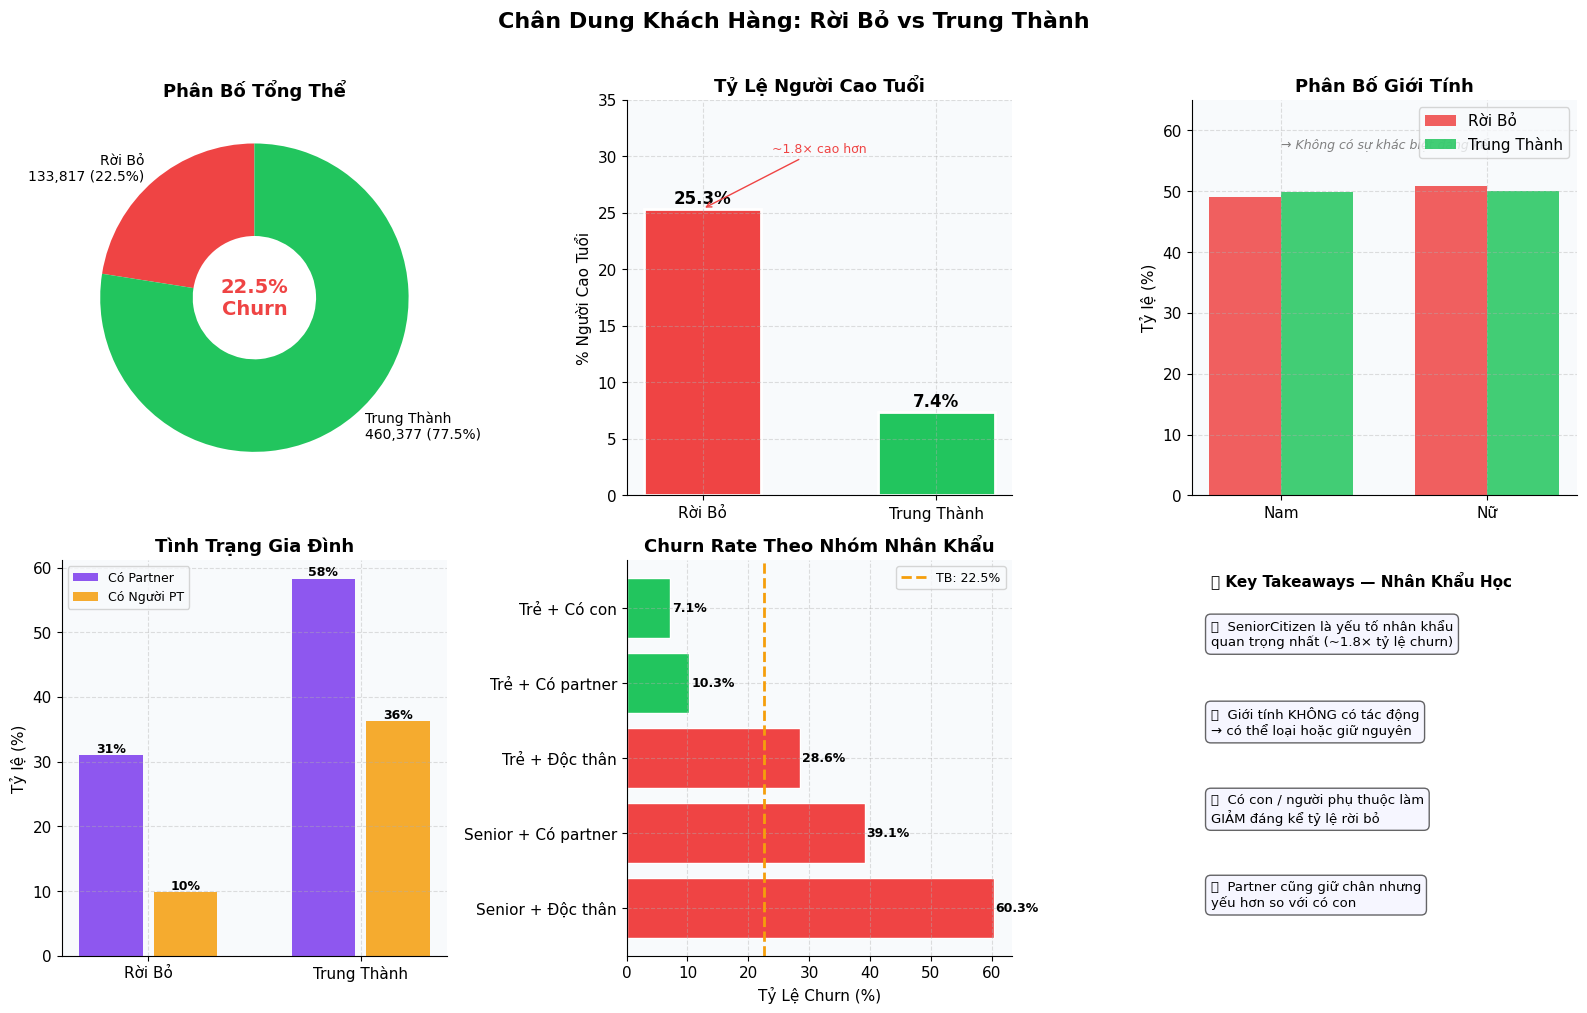

✅ Phần 2 hoàn thành!


In [8]:
# ════════════════════════════════════════════════════════
# PHẦN 2: Chân dung nhân khẩu học
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chân Dung Khách Hàng: Rời Bỏ vs Trung Thành',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Donut chart tổng thể
ax = axes[0, 0]
sizes  = [df['Churn'].sum(), (df['Churn']==0).sum()]
labels = [f'Rời Bỏ\n{sizes[0]:,} ({sizes[0]/N*100:.1f}%)',
          f'Trung Thành\n{sizes[1]:,} ({sizes[1]/N*100:.1f}%)']
ax.pie(sizes, labels=labels, colors=[CHURN_COLOR, RETAIN_COLOR],
       startangle=90, wedgeprops=dict(width=0.6),
       textprops=dict(fontsize=10))
ax.set_title('Phân Bố Tổng Thể', fontweight='bold')
ax.text(0, 0, f'{sizes[0]/N*100:.1f}%\nChurn', ha='center', va='center',
        fontsize=14, fontweight='bold', color=CHURN_COLOR)

# 2. SeniorCitizen
ax = axes[0, 1]
sc = [churn_df['SeniorCitizen'].mean()*100, retain_df['SeniorCitizen'].mean()*100]
bars = ax.bar(['Rời Bỏ','Trung Thành'], sc,
              color=[CHURN_COLOR, RETAIN_COLOR], width=0.5, edgecolor='white', linewidth=2)
ax.set_ylabel('% Người Cao Tuổi')
ax.set_title('Tỷ Lệ Người Cao Tuổi', fontweight='bold')
ax.set_ylim(0, 35)
for bar, val in zip(bars, sc):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=12)
ax.annotate('~1.8× cao hơn', xy=(0, sc[0]), xytext=(0.5, sc[0]+5),
            fontsize=9, color=CHURN_COLOR, ha='center',
            arrowprops=dict(arrowstyle='->', color=CHURN_COLOR))

# 3. Gender
ax = axes[0, 2]
gc = churn_df['gender'].value_counts(normalize=True)*100
gr = retain_df['gender'].value_counts(normalize=True)*100
x = np.arange(2); w = 0.35
ax.bar(x-w/2, [gc.get('Male',0), gc.get('Female',0)], w,
       label='Rời Bỏ', color=CHURN_COLOR, alpha=0.85)
ax.bar(x+w/2, [gr.get('Male',0), gr.get('Female',0)], w,
       label='Trung Thành', color=RETAIN_COLOR, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Nam','Nữ'])
ax.set_ylabel('Tỷ lệ (%)')
ax.set_title('Phân Bố Giới Tính', fontweight='bold')
ax.legend(); ax.set_ylim(0, 65)
ax.text(0.5, 57, '→ Không có sự khác biệt đáng kể', ha='center',
        fontsize=9, color='gray', style='italic', transform=ax.transData)

# 4. Partner & Dependents
ax = axes[1, 0]
groups_data = {
    'Có Partner':   [churn_df['Partner'].mean()*100,  retain_df['Partner'].mean()*100],
    'Có Người PT':  [churn_df['Dependents'].mean()*100, retain_df['Dependents'].mean()*100],
}
x2 = np.arange(2)
for i, (lbl, vals) in enumerate(groups_data.items()):
    off = (i-0.5)*0.35
    bars2 = ax.bar(x2+off, vals, 0.3, label=lbl,
                   color=[PALETTE['primary'], PALETTE['accent']][i], alpha=0.85)
    for bar, val in zip(bars2, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%',
                ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels(['Rời Bỏ','Trung Thành'])
ax.set_ylabel('Tỷ lệ (%)')
ax.set_title('Tình Trạng Gia Đình', fontweight='bold')
ax.legend(fontsize=9)

# 5. Churn rate theo nhóm kết hợp
ax = axes[1, 1]
grp_map = {
    'Senior + Độc thân':  df[(df['SeniorCitizen']==1)&(df['Partner']==0)]['Churn'].mean()*100,
    'Senior + Có partner':df[(df['SeniorCitizen']==1)&(df['Partner']==1)]['Churn'].mean()*100,
    'Trẻ + Độc thân':     df[(df['SeniorCitizen']==0)&(df['Partner']==0)]['Churn'].mean()*100,
    'Trẻ + Có partner':   df[(df['SeniorCitizen']==0)&(df['Partner']==1)]['Churn'].mean()*100,
    'Trẻ + Có con':       df[(df['SeniorCitizen']==0)&(df['Dependents']==1)]['Churn'].mean()*100,
}
avg_rate = df['Churn'].mean()*100
bar_c = [CHURN_COLOR if v > avg_rate else RETAIN_COLOR for v in grp_map.values()]
bars3 = ax.barh(list(grp_map.keys()), list(grp_map.values()),
                color=bar_c, edgecolor='white', linewidth=1)
ax.axvline(avg_rate, color=PALETTE['accent'], linestyle='--', linewidth=2,
           label=f'TB: {avg_rate:.1f}%')
ax.set_xlabel('Tỷ Lệ Churn (%)')
ax.set_title('Churn Rate Theo Nhóm Nhân Khẩu', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars3, grp_map.values()):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# 6. Insight box
ax = axes[1, 2]
ax.axis('off')
ax.text(0.05, 0.97, "💡 Key Takeaways — Nhân Khẩu Học",
        fontsize=11, fontweight='bold', transform=ax.transAxes, va='top')
insights = [
    ("🔴", "SeniorCitizen là yếu tố nhân khẩu\nquan trọng nhất (~1.8× tỷ lệ churn)"),
    ("🟡", "Giới tính KHÔNG có tác động\n→ có thể loại hoặc giữ nguyên"),
    ("🟢", "Có con / người phụ thuộc làm\nGIẢM đáng kể tỷ lệ rời bỏ"),
    ("🔵", "Partner cũng giữ chân nhưng\nyếu hơn so với có con"),
]
y_pos = 0.85
for icon, text in insights:
    ax.text(0.05, y_pos, f"{icon}  {text}", fontsize=9.5,
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0ff', alpha=0.6))
    y_pos -= 0.22

plt.tight_layout()
plt.savefig('part2_demographic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phần 2 hoàn thành!")


---
## Phần 3 · Hành Trình Sử Dụng Dịch Vụ (Tenure)

> **Câu hỏi:** Khi nào khách hàng rời bỏ? Có "cửa sổ nguy hiểm" nào không?

**Giả thuyết:** Churn tập trung cao ở tháng đầu (honeymoon effect) và giảm mạnh sau 24 tháng.


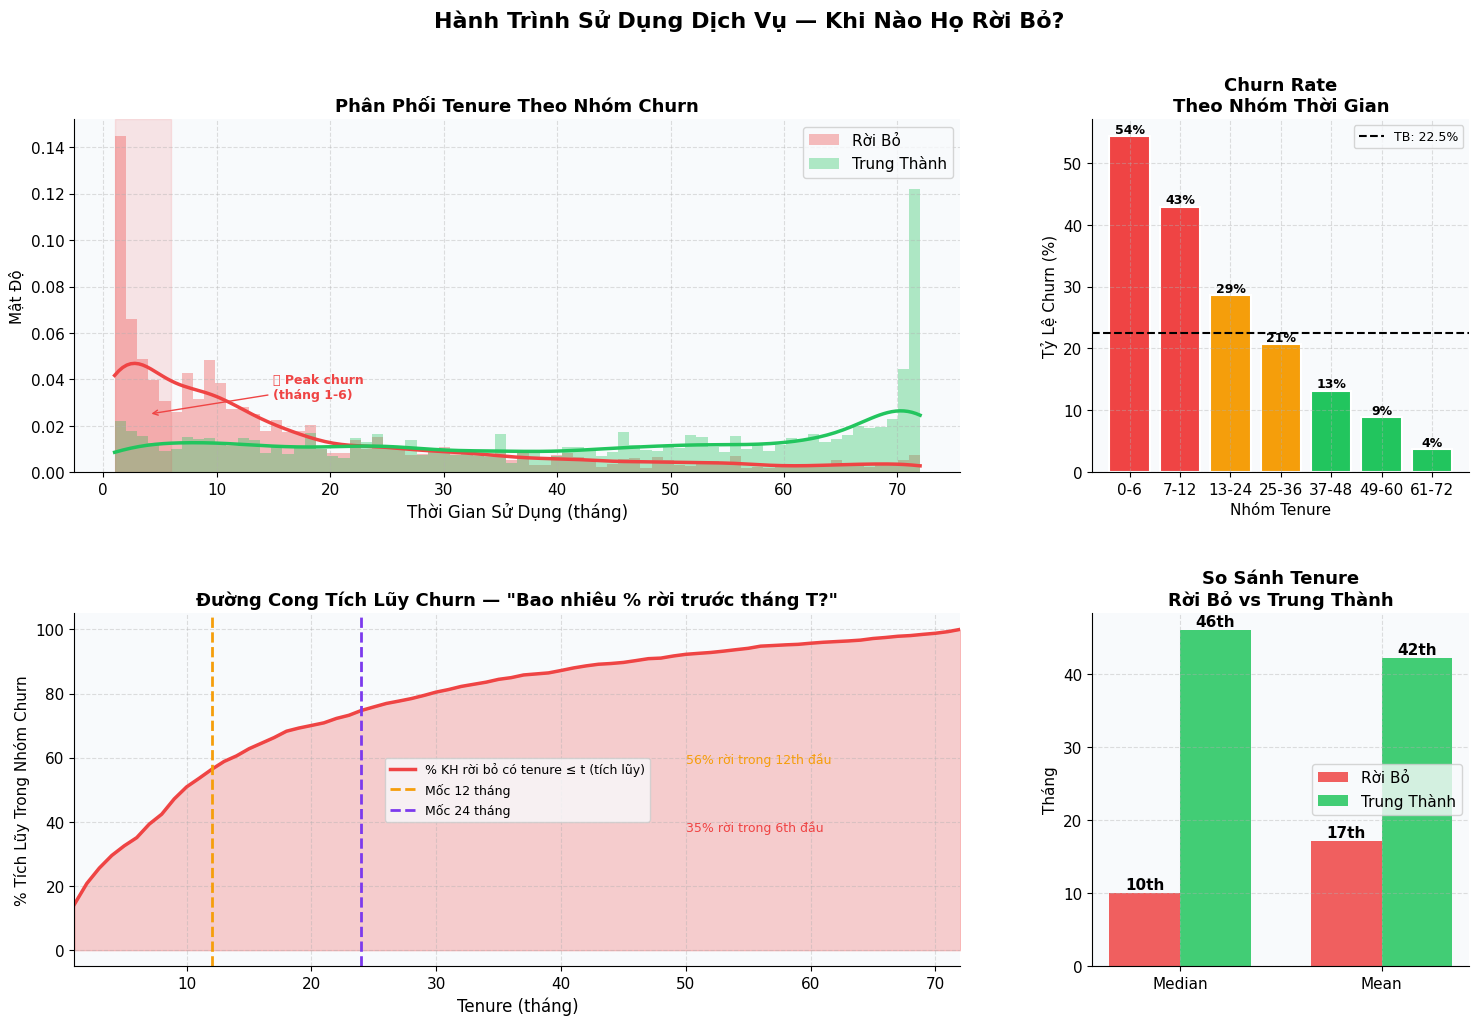

✅ Phần 3 hoàn thành!
   Median tenure churn : 10 tháng  |  retain: 46 tháng
   % churn trong 6th đầu: 35.1%  |  12th đầu: 56.3%


In [9]:
# ════════════════════════════════════════════════════════
# PHẦN 3: Tenure — Khi nào họ rời bỏ?
# ════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Hành Trình Sử Dụng Dịch Vụ — Khi Nào Họ Rời Bỏ?',
             fontsize=16, fontweight='bold')

# 1. KDE + Histogram tenure
ax1 = fig.add_subplot(gs[0, :2])
for color, group, name in [(CHURN_COLOR, churn_df, 'Rời Bỏ'),
                             (RETAIN_COLOR, retain_df, 'Trung Thành')]:
    ax1.hist(group['tenure'], bins=72, density=True, alpha=0.35, color=color, label=name)
    kde = gaussian_kde(group['tenure'], bw_method=0.15)
    xr  = np.linspace(1, 72, 200)
    ax1.plot(xr, kde(xr), color=color, linewidth=2.5)

ax1.axvspan(1, 6, alpha=0.12, color=CHURN_COLOR)
ax1.set_xlabel('Thời Gian Sử Dụng (tháng)', fontsize=12)
ax1.set_ylabel('Mật Độ')
ax1.set_title('Phân Phối Tenure Theo Nhóm Churn', fontweight='bold')
ax1.legend()
ax1.annotate('🔴 Peak churn\n(tháng 1-6)', xy=(4, 0.025), xytext=(15, 0.032),
             fontsize=9, color=CHURN_COLOR, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CHURN_COLOR))

# 2. Churn rate theo nhóm tenure
ax2 = fig.add_subplot(gs[0, 2])
bins_t = [0,6,12,24,36,48,60,72]
labels_t = ['0-6','7-12','13-24','25-36','37-48','49-60','61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins_t, labels=labels_t)
cbt = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
bar_ct = [CHURN_COLOR if v>30 else RETAIN_COLOR if v<20 else PALETTE['accent']
          for v in cbt.values]
bars = ax2.bar(cbt.index, cbt.values, color=bar_ct, edgecolor='white', linewidth=1.5)
ax2.axhline(df['Churn'].mean()*100, color='black', linestyle='--', linewidth=1.5,
            label=f"TB: {df['Churn'].mean()*100:.1f}%")
ax2.set_xlabel('Nhóm Tenure')
ax2.set_ylabel('Tỷ Lệ Churn (%)')
ax2.set_title('Churn Rate\nTheo Nhóm Thời Gian', fontweight='bold')
ax2.legend(fontsize=9)
for bar, val in zip(bars, cbt.values):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%',
             ha='center', fontsize=9, fontweight='bold')

# 3. Cumulative churn curve
ax3 = fig.add_subplot(gs[1, :2])
tv = np.arange(1, 73)
cum_churn = [(churn_df['tenure'] <= t).mean()*100 for t in tv]
ax3.fill_between(tv, cum_churn, alpha=0.25, color=CHURN_COLOR)
ax3.plot(tv, cum_churn, color=CHURN_COLOR, linewidth=2.5,
         label='% KH rời bỏ có tenure ≤ t (tích lũy)')
ax3.axvline(12, color=PALETTE['accent'],  linestyle='--', linewidth=2, label='Mốc 12 tháng')
ax3.axvline(24, color=PALETTE['primary'], linestyle='--', linewidth=2, label='Mốc 24 tháng')

pct_6  = (churn_df['tenure'] <= 6).mean()*100
pct_12 = (churn_df['tenure'] <= 12).mean()*100
ax3.text(50, pct_6+2,  f'{pct_6:.0f}% rời trong 6th đầu',  fontsize=9, color=CHURN_COLOR)
ax3.text(50, pct_12+2, f'{pct_12:.0f}% rời trong 12th đầu', fontsize=9, color=PALETTE['accent'])
ax3.set_xlabel('Tenure (tháng)', fontsize=12)
ax3.set_ylabel('% Tích Lũy Trong Nhóm Churn')
ax3.set_title('Đường Cong Tích Lũy Churn — "Bao nhiêu % rời trước tháng T?"',
              fontweight='bold')
ax3.legend(fontsize=9); ax3.set_xlim(1, 72)

# 4. Median / Mean so sánh
ax4 = fig.add_subplot(gs[1, 2])
med_c = churn_df['tenure'].median()
med_r = retain_df['tenure'].median()
mea_c = churn_df['tenure'].mean()
mea_r = retain_df['tenure'].mean()
x4 = np.arange(2); w4 = 0.35
b1 = ax4.bar(x4-w4/2, [med_c, mea_c], w4, label='Rời Bỏ',     color=CHURN_COLOR,  alpha=0.85)
b2 = ax4.bar(x4+w4/2, [med_r, mea_r], w4, label='Trung Thành', color=RETAIN_COLOR, alpha=0.85)
ax4.set_xticks(x4); ax4.set_xticklabels(['Median','Mean'])
ax4.set_ylabel('Tháng')
ax4.set_title('So Sánh Tenure\nRời Bỏ vs Trung Thành', fontweight='bold')
ax4.legend()
for bar, val in zip(list(b1)+list(b2), [med_c,mea_c,med_r,mea_r]):
    ax4.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}th',
             ha='center', fontsize=11, fontweight='bold')

plt.savefig('part3_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Phần 3 hoàn thành!")
print(f"   Median tenure churn : {med_c:.0f} tháng  |  retain: {med_r:.0f} tháng")
print(f"   % churn trong 6th đầu: {pct_6:.1f}%  |  12th đầu: {pct_12:.1f}%")


---
## Phần 4 · Tài Chính & Giá Cả

> **Câu hỏi:** Chi phí có phải nguyên nhân chính? Khách hàng nào "trả nhiều nhưng vẫn rời bỏ"?

**Giả thuyết:** Phí cao + tenure ngắn = chưa cảm nhận được giá trị → dễ rời bỏ nhất.


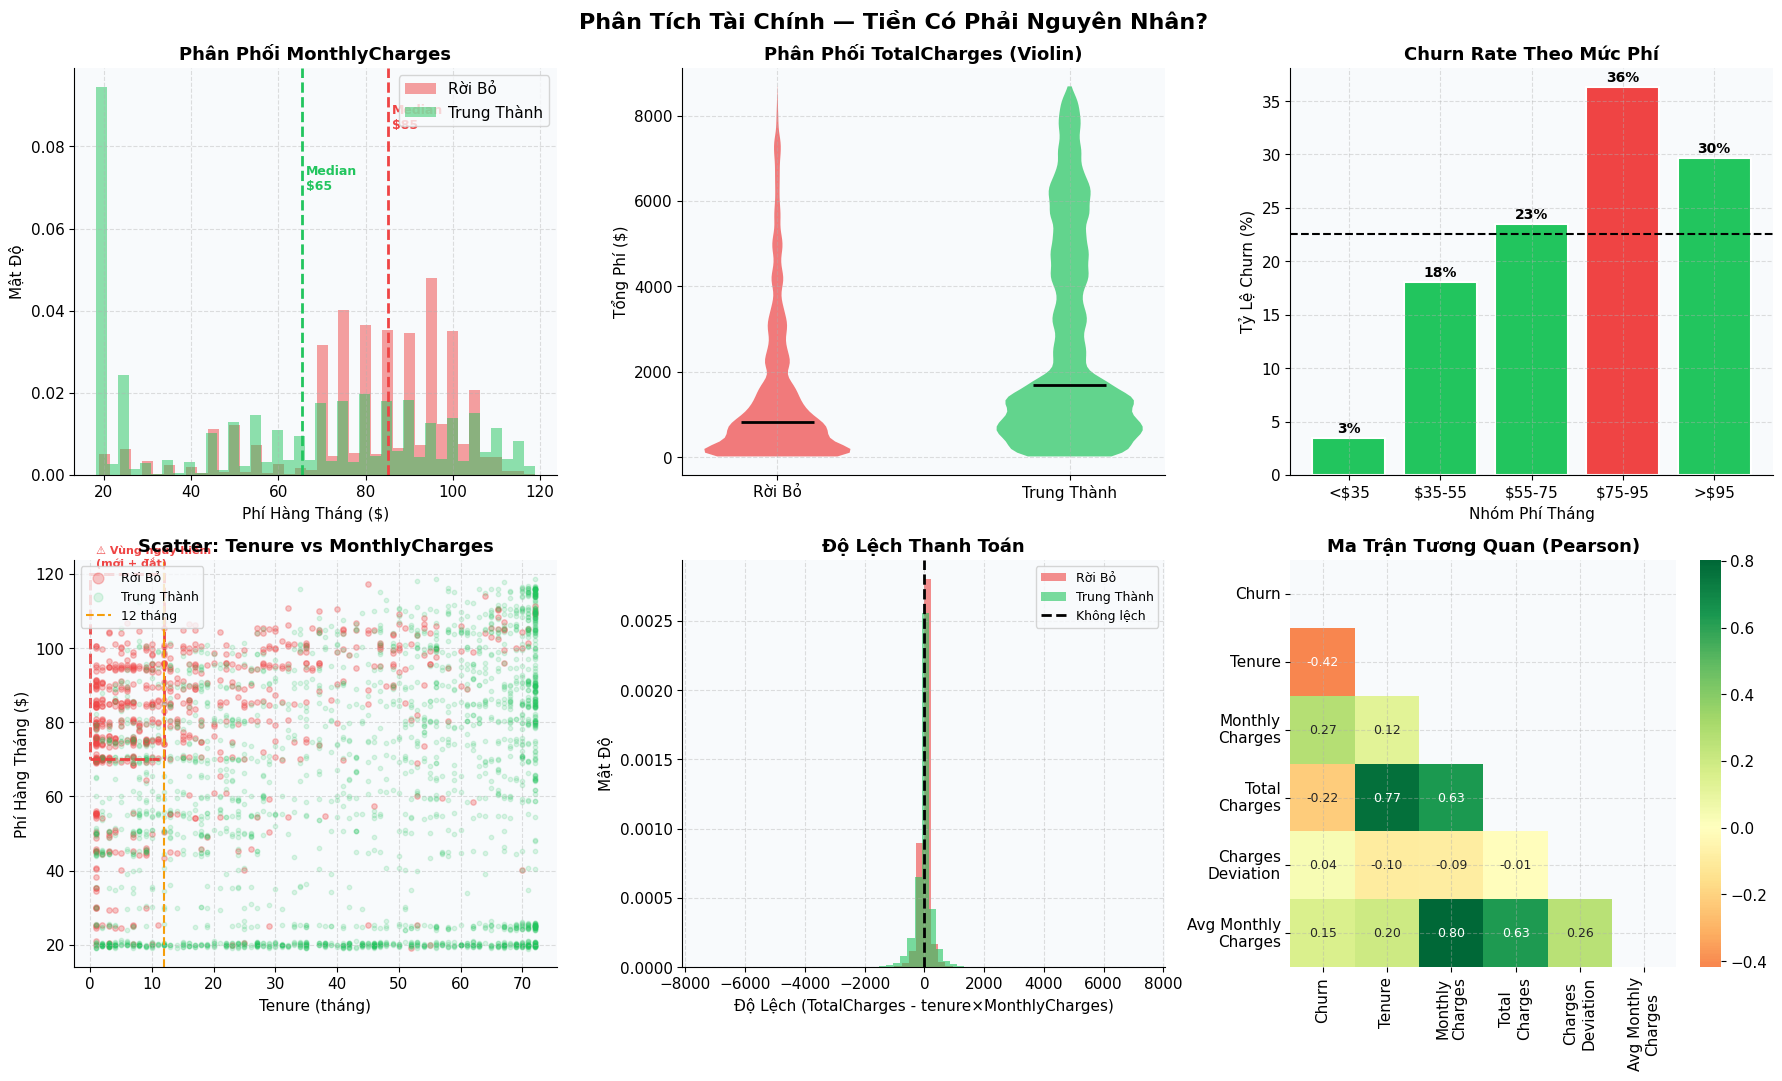

✅ Phần 4 hoàn thành!
   Median MonthlyCharges — Churn: $85.05  |  Retain: $65.40
   Correlation Churn~tenure        : -0.418
   Correlation Churn~MonthlyCharges: 0.273


In [10]:
# ════════════════════════════════════════════════════════
# PHẦN 4: Tài chính & giá cả
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Phân Tích Tài Chính — Tiền Có Phải Nguyên Nhân?',
             fontsize=16, fontweight='bold')

# 1. MonthlyCharges distribution
ax = axes[0, 0]
for color, group, name in [(CHURN_COLOR, churn_df, 'Rời Bỏ'),
                             (RETAIN_COLOR, retain_df, 'Trung Thành')]:
    ax.hist(group['MonthlyCharges'], bins=40, density=True, alpha=0.5, color=color, label=name)
    ax.axvline(group['MonthlyCharges'].median(), color=color, linestyle='--', linewidth=2)
ax.set_xlabel('Phí Hàng Tháng ($)'); ax.set_ylabel('Mật Độ')
ax.set_title('Phân Phối MonthlyCharges', fontweight='bold')
ax.legend()
mc_c = churn_df['MonthlyCharges'].median()
mc_r = retain_df['MonthlyCharges'].median()
ylim = ax.get_ylim()[1]
ax.text(mc_c+1, ylim*0.85, f'Median\n${mc_c:.0f}', color=CHURN_COLOR, fontsize=9, fontweight='bold')
ax.text(mc_r+1, ylim*0.70, f'Median\n${mc_r:.0f}', color=RETAIN_COLOR, fontsize=9, fontweight='bold')

# 2. TotalCharges violin
ax = axes[0, 1]
vp = ax.violinplot([churn_df['TotalCharges'], retain_df['TotalCharges']],
                    positions=[1,2], showmedians=True, showextrema=False)
vp['bodies'][0].set_facecolor(CHURN_COLOR);  vp['bodies'][0].set_alpha(0.7)
vp['bodies'][1].set_facecolor(RETAIN_COLOR); vp['bodies'][1].set_alpha(0.7)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
ax.set_xticks([1,2]); ax.set_xticklabels(['Rời Bỏ','Trung Thành'])
ax.set_ylabel('Tổng Phí ($)')
ax.set_title('Phân Phối TotalCharges (Violin)', fontweight='bold')

# 3. Churn rate by MonthlyCharges group
ax = axes[0, 2]
mc_bins = [0,35,55,75,95,120]
mc_lbs  = ['<$35','$35-55','$55-75','$75-95','>$95']
df['mc_group'] = pd.cut(df['MonthlyCharges'], bins=mc_bins, labels=mc_lbs)
cr_mc = df.groupby('mc_group', observed=True)['Churn'].mean()*100
bc = [CHURN_COLOR if v>30 else RETAIN_COLOR for v in cr_mc]
bars = ax.bar(cr_mc.index, cr_mc.values, color=bc, edgecolor='white', linewidth=1.5)
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)
ax.set_xlabel('Nhóm Phí Tháng'); ax.set_ylabel('Tỷ Lệ Churn (%)')
ax.set_title('Churn Rate Theo Mức Phí', fontweight='bold')
for bar, val in zip(bars, cr_mc.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%',
            ha='center', fontsize=10, fontweight='bold')

# 4. Scatter tenure vs MonthlyCharges
ax = axes[1, 0]
sidx = np.random.choice(len(df), 3000, replace=False)
s = df.iloc[sidx]
ax.scatter(s[s['Churn']==1]['tenure'], s[s['Churn']==1]['MonthlyCharges'],
           alpha=0.3, s=15, c=CHURN_COLOR, label='Rời Bỏ')
ax.scatter(s[s['Churn']==0]['tenure'], s[s['Churn']==0]['MonthlyCharges'],
           alpha=0.15, s=10, c=RETAIN_COLOR, label='Trung Thành')
ax.axvline(12, color=PALETTE['accent'], linestyle='--', linewidth=1.5, label='12 tháng')
rect = plt.Rectangle((0,70),12,50, linewidth=2,
                      edgecolor=CHURN_COLOR, facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(1,122,'⚠️ Vùng nguy hiểm\n(mới + đắt)', fontsize=8, color=CHURN_COLOR, fontweight='bold')
ax.set_xlabel('Tenure (tháng)'); ax.set_ylabel('Phí Hàng Tháng ($)')
ax.set_title('Scatter: Tenure vs MonthlyCharges', fontweight='bold')
ax.legend(fontsize=9, markerscale=2)

# 5. Charges deviation
ax = axes[1, 1]
ax.hist(churn_df['charges_deviation'],  bins=60, density=True, alpha=0.6,
        color=CHURN_COLOR,  label='Rời Bỏ')
ax.hist(retain_df['charges_deviation'], bins=60, density=True, alpha=0.6,
        color=RETAIN_COLOR, label='Trung Thành')
ax.axvline(0, color='black', linewidth=2, linestyle='--', label='Không lệch')
ax.set_xlabel('Độ Lệch (TotalCharges - tenure×MonthlyCharges)')
ax.set_ylabel('Mật Độ')
ax.set_title('Độ Lệch Thanh Toán', fontweight='bold')
ax.legend(fontsize=9)

# 6. Correlation heatmap
ax = axes[1, 2]
cvars = ['Churn','tenure','MonthlyCharges','TotalCharges','charges_deviation','avg_monthly_charges']
clbls = ['Churn','Tenure','Monthly\nCharges','Total\nCharges','Charges\nDeviation','Avg Monthly\nCharges']
corr = df[cvars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, mask=mask, xticklabels=clbls, yticklabels=clbls,
            annot_kws={'size':9})
ax.set_title('Ma Trận Tương Quan (Pearson)', fontweight='bold')

plt.tight_layout()
plt.savefig('part4_financial.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phần 4 hoàn thành!")
print(f"   Median MonthlyCharges — Churn: ${mc_c:.2f}  |  Retain: ${mc_r:.2f}")
print(f"   Correlation Churn~tenure        : {df['Churn'].corr(df['tenure']):.3f}")
print(f"   Correlation Churn~MonthlyCharges: {df['Churn'].corr(df['MonthlyCharges']):.3f}")


════════════════════════════════════════════════════════════
📊 FINANCE SUMMARY — CLV & REVENUE IMPACT
════════════════════════════════════════════════════════════

👥 Phân bổ khách hàng:
   Churn  : 133,817 KH (22.5%)
   Retain : 460,377 KH (77.5%)

💎 Customer Lifetime Value (CLV thực tế):
   Median CLV — Churn  : $830
   Median CLV — Retain : $1,689
   CLV Ratio           : 2.0x  ← Retain đáng giá hơn 2.0x
   CLV Gap (mất đi)    : $859 / khách hàng

💸 Ước tính Revenue bị mất hàng tháng:
   Monthly Revenue at Risk (median): $11,381,136
   Monthly Revenue at Risk (mean)  : $10,919,136
   Annual Projection               : $131,029,632

   → Nếu giữ lại được 10% khách hàng sắp rời bỏ:
     Tiết kiệm ≈ $1,091,914/tháng
════════════════════════════════════════════════════════════


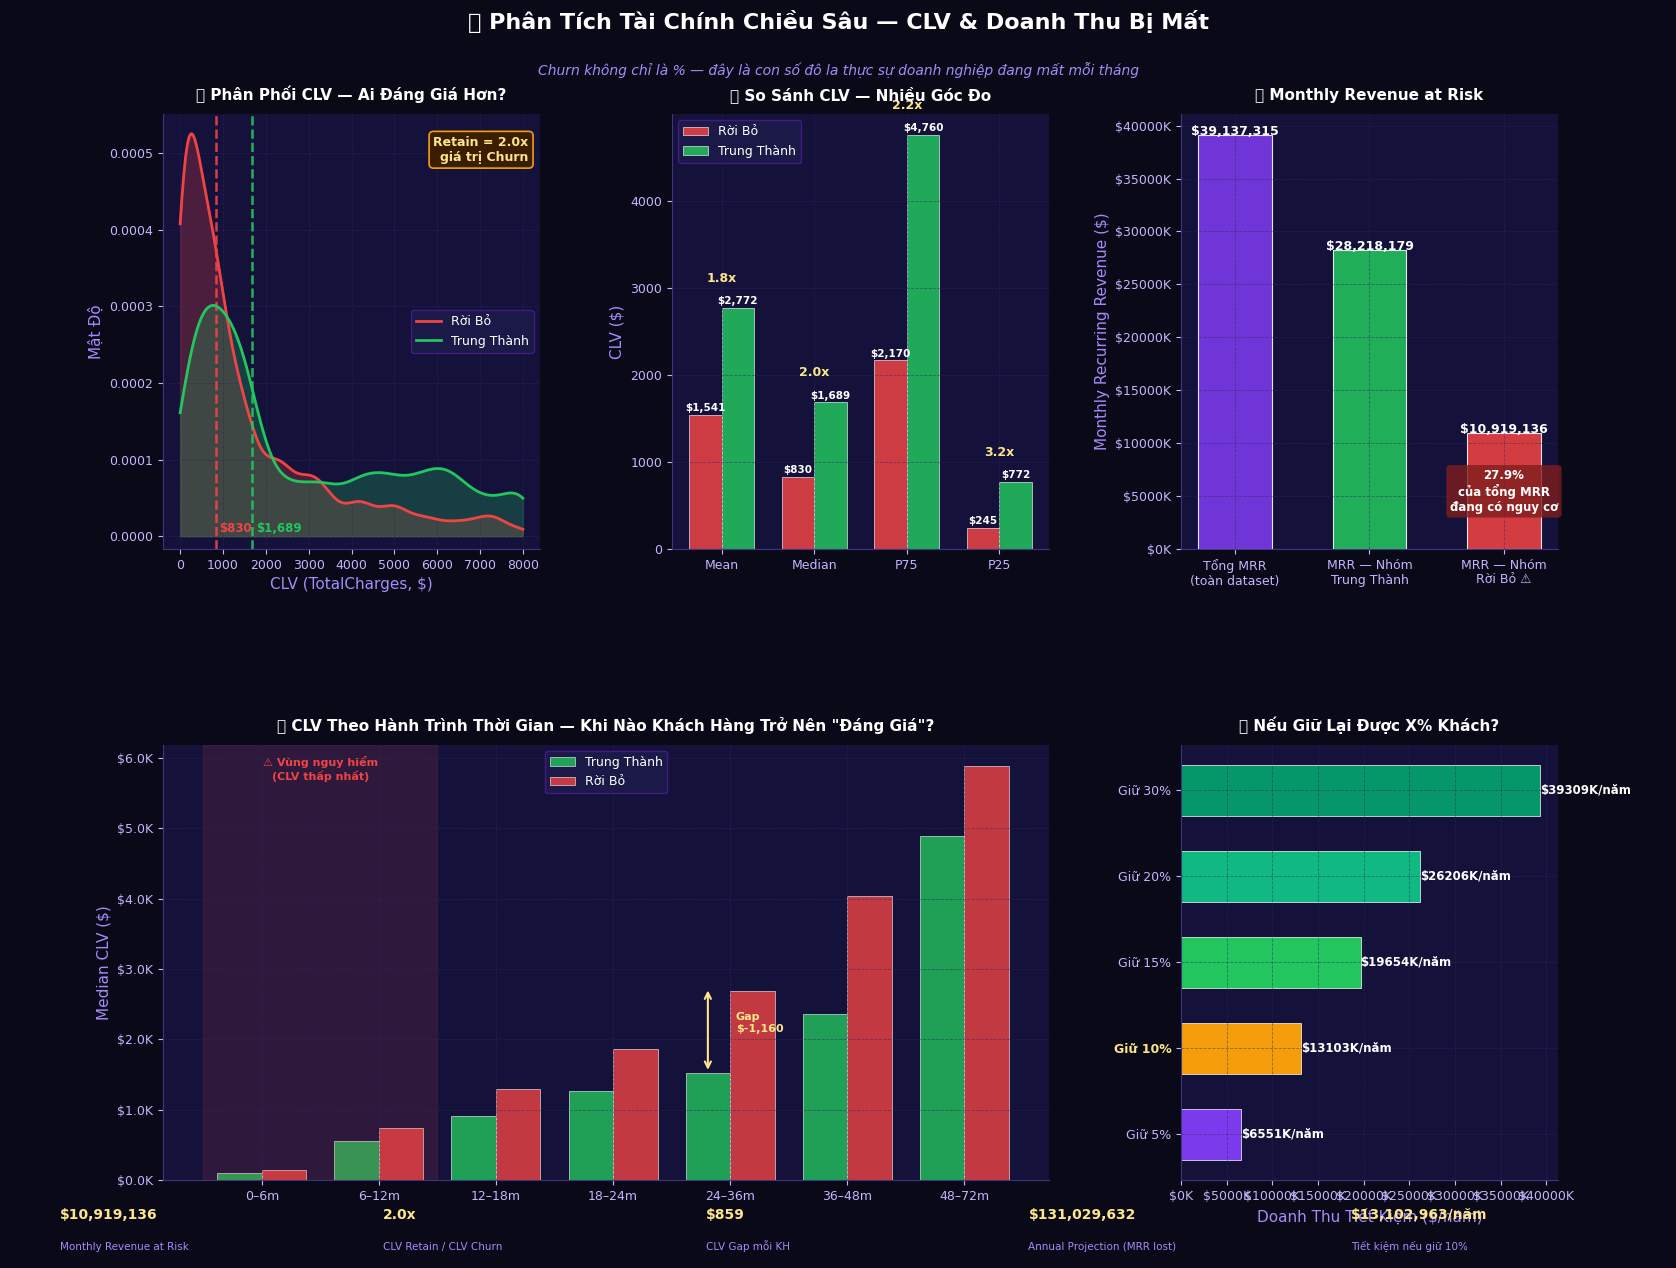


✅ CLV & Revenue Analysis hoàn thành!
   → Monthly Revenue at Risk : $10,919,136
   → CLV Ratio (Retain/Churn): 2.0x
   → CLV Gap mỗi khách hàng : $859
   → Annual Revenue at Risk  : $131,029,632


In [18]:
# ════════════════════════════════════════════════════════════════════════
# PHẦN 4 · BỔ SUNG — CLV & REVENUE LOSS ANALYSIS
# Thêm vào CUỐI cell hiện tại của Phần 4 (sau correlation heatmap)
# ════════════════════════════════════════════════════════════════════════

# ── [MARKDOWN CELL — chèn trước code cell bên dưới] ─────────────────────
"""
### 💰 Phần 4.1 · Customer Lifetime Value & Doanh Thu Bị Mất

> **Câu hỏi Finance:** Churn không chỉ là con số phần trăm —
> doanh nghiệp đang mất **bao nhiêu đô la thực sự** mỗi tháng?
> Và một khách hàng trung thành đáng giá gấp mấy lần khách hàng rời bỏ?
"""

# ════════════════════════════════════════════════════════════════════════
# CELL CODE — CLV Analysis + Revenue Loss
# ════════════════════════════════════════════════════════════════════════

# ── 1. Tính CLV cho từng khách hàng ──────────────────────────────────────
# CLV đơn giản: tổng doanh thu đã thực thu = TotalCharges
# CLV projected: MonthlyCharges × tenure (kỳ vọng tuyến tính)
df['CLV_actual']    = df['TotalCharges']
df['CLV_projected'] = df['MonthlyCharges'] * df['tenure']

# ── 2. Tính các metric tài chính cốt lõi ─────────────────────────────────
n_churn  = df['Churn'].sum()
n_retain = (df['Churn'] == 0).sum()
n_total  = len(df)

# ── QUAN TRỌNG: Rebuild sub-dataframes để có CLV columns mới
# churn_df / retain_df được tạo trước khi thêm CLV → cần sync lại
churn_df  = df[df['Churn'] == 1].copy()
retain_df = df[df['Churn'] == 0].copy()

# Median CLV
clv_churn_med  = churn_df['CLV_actual'].median()
clv_retain_med = retain_df['CLV_actual'].median()
clv_ratio      = clv_retain_med / clv_churn_med

# Median MonthlyCharges
mc_churn  = churn_df['MonthlyCharges'].median()
mc_retain = retain_df['MonthlyCharges'].median()

# ── 3. Ước tính Revenue bị mất mỗi tháng ─────────────────────────────────
# Approach 1: Monthly Revenue at Risk = n_churn × median MonthlyCharges (churn group)
monthly_rev_lost_median = n_churn * mc_churn

# Approach 2: Mean-based (thường cao hơn vì right-skewed)
monthly_rev_lost_mean   = n_churn * churn_df['MonthlyCharges'].mean()

# Approach 3: Annual projection
annual_rev_lost = monthly_rev_lost_mean * 12

# ── 4. CLV gap analysis ───────────────────────────────────────────────────
clv_gap = clv_retain_med - clv_churn_med

# Print summary trước khi vẽ
print("═"*60)
print("📊 FINANCE SUMMARY — CLV & REVENUE IMPACT")
print("═"*60)
print(f"\n👥 Phân bổ khách hàng:")
print(f"   Churn  : {n_churn:,} KH ({n_churn/n_total*100:.1f}%)")
print(f"   Retain : {n_retain:,} KH ({n_retain/n_total*100:.1f}%)")

print(f"\n💎 Customer Lifetime Value (CLV thực tế):")
print(f"   Median CLV — Churn  : ${clv_churn_med:,.0f}")
print(f"   Median CLV — Retain : ${clv_retain_med:,.0f}")
print(f"   CLV Ratio           : {clv_ratio:.1f}x  ← Retain đáng giá hơn {clv_ratio:.1f}x")
print(f"   CLV Gap (mất đi)    : ${clv_gap:,.0f} / khách hàng")

print(f"\n💸 Ước tính Revenue bị mất hàng tháng:")
print(f"   Monthly Revenue at Risk (median): ${monthly_rev_lost_median:,.0f}")
print(f"   Monthly Revenue at Risk (mean)  : ${monthly_rev_lost_mean:,.0f}")
print(f"   Annual Projection               : ${annual_rev_lost:,.0f}")
print(f"\n   → Nếu giữ lại được 10% khách hàng sắp rời bỏ:")
print(f"     Tiết kiệm ≈ ${monthly_rev_lost_mean*0.1:,.0f}/tháng")
print("═"*60)


# ════════════════════════════════════════════════════════════════════════
# VISUALIZATION — 3 panels: CLV Distribution | Revenue Breakdown | ROI
# ════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#0a0918')

# Tiêu đề lớn
fig.text(0.5, 0.97,
         '💰 Phân Tích Tài Chính Chiều Sâu — CLV & Doanh Thu Bị Mất',
         ha='center', va='top', fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.93,
         'Churn không chỉ là % — đây là con số đô la thực sự doanh nghiệp đang mất mỗi tháng',
         ha='center', va='top', fontsize=10, color='#a78bfa', style='italic')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       top=0.89, bottom=0.07)

# ─── Helper style ────────────────────────────────────────────────────────
def dark_ax(ax, title=''):
    ax.set_facecolor('#14123a')
    for s in ax.spines.values():
        s.set_edgecolor('#3d3580')
        s.set_linewidth(0.8)
    ax.tick_params(colors='#c4b5fd', labelsize=9)
    ax.xaxis.label.set_color('#a78bfa')
    ax.yaxis.label.set_color('#a78bfa')
    ax.grid(color='#2d2760', alpha=0.5, linestyle='--', linewidth=0.6)
    if title:
        ax.set_title(title, color='white', fontweight='bold', fontsize=11, pad=10)

# ────────────────────────────────────────────────────────────────────────
# Panel 1 (row 0, col 0) — CLV Distribution: KDE + Median Lines
# ────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
dark_ax(ax1, '📊 Phân Phối CLV — Ai Đáng Giá Hơn?')

from scipy.stats import gaussian_kde

for grp, col, lbl, med in [
    (churn_df,  CHURN_COLOR,  'Rời Bỏ',     clv_churn_med),
    (retain_df, RETAIN_COLOR, 'Trung Thành', clv_retain_med),
]:
    data = grp['CLV_actual'].clip(0, 8000)
    kde  = gaussian_kde(data, bw_method=0.15)
    xs   = np.linspace(0, 8000, 400)
    ys   = kde(xs)
    ax1.fill_between(xs, ys, alpha=0.25, color=col)
    ax1.plot(xs, ys, color=col, linewidth=2, label=lbl)
    ax1.axvline(med, color=col, linestyle='--', linewidth=1.8, alpha=0.9)
    # Median annotation
    ax1.text(med + 80, ax1.get_ylim()[1] * 0.01 if ax1.get_ylim()[1] > 0 else 0.0003,
             f'${med:,.0f}', color=col, fontsize=8.5, fontweight='bold')

ax1.set_xlabel('CLV (TotalCharges, $)')
ax1.set_ylabel('Mật Độ')
ax1.legend(facecolor='#1e1b4b', edgecolor='#4c1d95', labelcolor='white', fontsize=9)

# Annotation ratio
ax1.text(0.97, 0.95,
         f'Retain = {clv_ratio:.1f}x\ngiá trị Churn',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=9, color='#fde68a', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.35', facecolor='#3b1d00', edgecolor='#f59e0b', linewidth=1.2))

# Re-draw sau khi có ylim thật
ax1.relim(); ax1.autoscale_view()

# ────────────────────────────────────────────────────────────────────────
# Panel 2 (row 0, col 1) — CLV Breakdown Bar: Mean, Median, P75, P25
# ────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dark_ax(ax2, '📐 So Sánh CLV — Nhiều Góc Đo')

metrics = ['Mean', 'Median', 'P75', 'P25']
clv_c   = [churn_df['CLV_actual'].mean(),
            churn_df['CLV_actual'].median(),
            churn_df['CLV_actual'].quantile(0.75),
            churn_df['CLV_actual'].quantile(0.25)]
clv_r   = [retain_df['CLV_actual'].mean(),
            retain_df['CLV_actual'].median(),
            retain_df['CLV_actual'].quantile(0.75),
            retain_df['CLV_actual'].quantile(0.25)]

x_pos = np.arange(len(metrics))
w     = 0.35
b1 = ax2.bar(x_pos - w/2, clv_c, w, color=CHURN_COLOR,  alpha=0.85,
             edgecolor='white', linewidth=0.5, label='Rời Bỏ')
b2 = ax2.bar(x_pos + w/2, clv_r, w, color=RETAIN_COLOR, alpha=0.85,
             edgecolor='white', linewidth=0.5, label='Trung Thành')

for bar, val in list(zip(b1, clv_c)) + list(zip(b2, clv_r)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 40,
             f'${val:,.0f}', ha='center', fontsize=7.5,
             color='white', fontweight='bold')

# Ratio labels trên mỗi cặp
for i, (c, r) in enumerate(zip(clv_c, clv_r)):
    ratio = r / c if c > 0 else 0
    ax2.text(i, max(c, r) + 300,
             f'{ratio:.1f}x', ha='center', fontsize=9,
             color='#fde68a', fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics, color='#c4b5fd')
ax2.set_ylabel('CLV ($)')
ax2.legend(facecolor='#1e1b4b', edgecolor='#4c1d95', labelcolor='white', fontsize=9)

# ────────────────────────────────────────────────────────────────────────
# Panel 3 (row 0, col 2) — Monthly Revenue at Risk: Stacked visual
# ────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
dark_ax(ax3, '🚨 Monthly Revenue at Risk')

# Tổng Monthly Revenue
total_monthly = df['MonthlyCharges'].sum()
rev_churn     = churn_df['MonthlyCharges'].sum()
rev_retain    = retain_df['MonthlyCharges'].sum()

categories = ['Tổng MRR\n(toàn dataset)', 'MRR — Nhóm\nTrung Thành', 'MRR — Nhóm\nRời Bỏ ⚠️']
values     = [total_monthly, rev_retain, rev_churn]
colors_bar = [PALETTE['primary'], RETAIN_COLOR, CHURN_COLOR]

bars = ax3.bar(categories, values, color=colors_bar, edgecolor='white',
               linewidth=0.8, width=0.55, alpha=0.88)

# Value labels
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 3000,
             f'${val:,.0f}', ha='center', fontsize=9,
             color='white', fontweight='bold')

# % annotation trên cột rời bỏ
pct_at_risk = rev_churn / total_monthly * 100
ax3.text(2, rev_churn / 2,
         f'{pct_at_risk:.1f}%\ncủa tổng MRR\nđang có nguy cơ',
         ha='center', va='center', fontsize=8.5,
         color='white', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#7f1d1d', alpha=0.8, edgecolor='none'))

ax3.set_ylabel('Monthly Recurring Revenue ($)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ────────────────────────────────────────────────────────────────────────
# Panel 4 (row 1, col 0-1) — CLV theo tenure × Churn: heatmap-style scatter
# ────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
dark_ax(ax4, '⏳ CLV Theo Hành Trình Thời Gian — Khi Nào Khách Hàng Trở Nên "Đáng Giá"?')

# Tính CLV trung bình theo tenure bin và churn
tenure_cuts = [0, 6, 12, 18, 24, 36, 48, 72]
tenure_lbls = ['0–6m', '6–12m', '12–18m', '18–24m', '24–36m', '36–48m', '48–72m']
df['t_bin']  = pd.cut(df['tenure'], bins=tenure_cuts, labels=tenure_lbls)

clv_by_tenure = df.groupby(['t_bin', 'Churn'], observed=True)['CLV_actual'].median().unstack()
clv_by_tenure.columns = ['Trung Thành', 'Rời Bỏ']

x_pos4 = np.arange(len(tenure_lbls))
w4     = 0.38
b_r = ax4.bar(x_pos4 - w4/2, clv_by_tenure['Trung Thành'], w4,
              color=RETAIN_COLOR, alpha=0.8, edgecolor='white', linewidth=0.5,
              label='Trung Thành')
b_c = ax4.bar(x_pos4 + w4/2, clv_by_tenure['Rời Bỏ'], w4,
              color=CHURN_COLOR, alpha=0.8, edgecolor='white', linewidth=0.5,
              label='Rời Bỏ')

# CLV Gap arrow & annotation tại mốc 24–36m
if '24–36m' in clv_by_tenure.index:
    idx_24 = list(tenure_lbls).index('24–36m')
    r_val  = clv_by_tenure.loc['24–36m', 'Trung Thành']
    c_val  = clv_by_tenure.loc['24–36m', 'Rời Bỏ']
    ax4.annotate('', xy=(idx_24 - w4/2, r_val), xytext=(idx_24 - w4/2, c_val + 50),
                 arrowprops=dict(arrowstyle='<->', color='#fde68a', lw=1.5))
    ax4.text(idx_24 + 0.05, (r_val + c_val) / 2,
             f'Gap\n${r_val - c_val:,.0f}', fontsize=8,
             color='#fde68a', fontweight='bold')

ax4.set_xticks(x_pos4)
ax4.set_xticklabels(tenure_lbls, color='#c4b5fd')
ax4.set_ylabel('Median CLV ($)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
ax4.legend(facecolor='#1e1b4b', edgecolor='#4c1d95', labelcolor='white', fontsize=9)

# Shade "Cửa sổ nguy hiểm"
ax4.axvspan(-0.5, 1.5, alpha=0.12, color=CHURN_COLOR)
ax4.text(0.5, ax4.get_ylim()[1] * 0.92 if ax4.get_ylim()[1] > 0 else 100,
         '⚠️ Vùng nguy hiểm\n(CLV thấp nhất)',
         ha='center', fontsize=8, color=CHURN_COLOR, fontweight='bold')

# ────────────────────────────────────────────────────────────────────────
# Panel 5 (row 1, col 2) — ROI Retention: Nếu giữ X% khách hàng
# ────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
dark_ax(ax5, '🎯 Nếu Giữ Lại Được X% Khách?')

retention_pcts = [5, 10, 15, 20, 30]
saved_monthly  = [rev_churn * p / 100 for p in retention_pcts]
saved_annual   = [v * 12 for v in saved_monthly]

bar_colors = [PALETTE['primary'], PALETTE['accent'],
              '#22c55e', '#10b981', '#059669']

bars5 = ax5.barh([f'Giữ {p}%' for p in retention_pcts],
                  saved_annual, color=bar_colors,
                  edgecolor='white', linewidth=0.5, height=0.6)

for bar, val in zip(bars5, saved_annual):
    ax5.text(val + 5000, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K/năm', va='center',
             fontsize=8.5, color='white', fontweight='bold')

ax5.set_xlabel('Doanh Thu Tiết Kiệm ($/năm)')
ax5.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Highlight dòng 10%
ax5.get_yticklabels()[1].set_color('#fde68a')
ax5.get_yticklabels()[1].set_fontweight('bold')

# ────────────────────────────────────────────────────────────────────────
# Finance KPI Banner — phía dưới
# ────────────────────────────────────────────────────────────────────────
kpi_ax = fig.add_axes([0.04, 0.01, 0.92, 0.04])
kpi_ax.set_facecolor('#1e1b4b')
kpi_ax.axis('off')

kpis = [
    ('Monthly Revenue at Risk', f'${rev_churn:,.0f}'),
    ('CLV Retain / CLV Churn', f'{clv_ratio:.1f}x'),
    ('CLV Gap mỗi KH', f'${clv_gap:,.0f}'),
    ('Annual Projection (MRR lost)', f'${rev_churn*12:,.0f}'),
    ('Tiết kiệm nếu giữ 10%', f'${rev_churn*12*0.10:,.0f}/năm'),
]

for i, (lbl, val) in enumerate(kpis):
    x = 0.03 + i * 0.195
    kpi_ax.text(x, 0.75, val, fontsize=10, color='#fde68a',
                fontweight='bold', transform=kpi_ax.transAxes)
    kpi_ax.text(x, 0.15, lbl, fontsize=7.5, color='#a78bfa',
                transform=kpi_ax.transAxes)

plt.savefig('part4_clv_revenue.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0918')
plt.show()
print("\n✅ CLV & Revenue Analysis hoàn thành!")
print(f"   → Monthly Revenue at Risk : ${rev_churn:,.0f}")
print(f"   → CLV Ratio (Retain/Churn): {clv_ratio:.1f}x")
print(f"   → CLV Gap mỗi khách hàng : ${clv_gap:,.0f}")
print(f"   → Annual Revenue at Risk  : ${rev_churn*12:,.0f}")


---
## Phần 5 · Hợp Đồng & Phương Thức Thanh Toán

> **Câu hỏi:** Loại hợp đồng nào là "bẫy churn" lớn nhất? Thanh toán tự động có giúp giữ chân?

**Giả thuyết:** Month-to-month = zero switching cost = churn cao nhất. Electronic check = ít cam kết hơn.


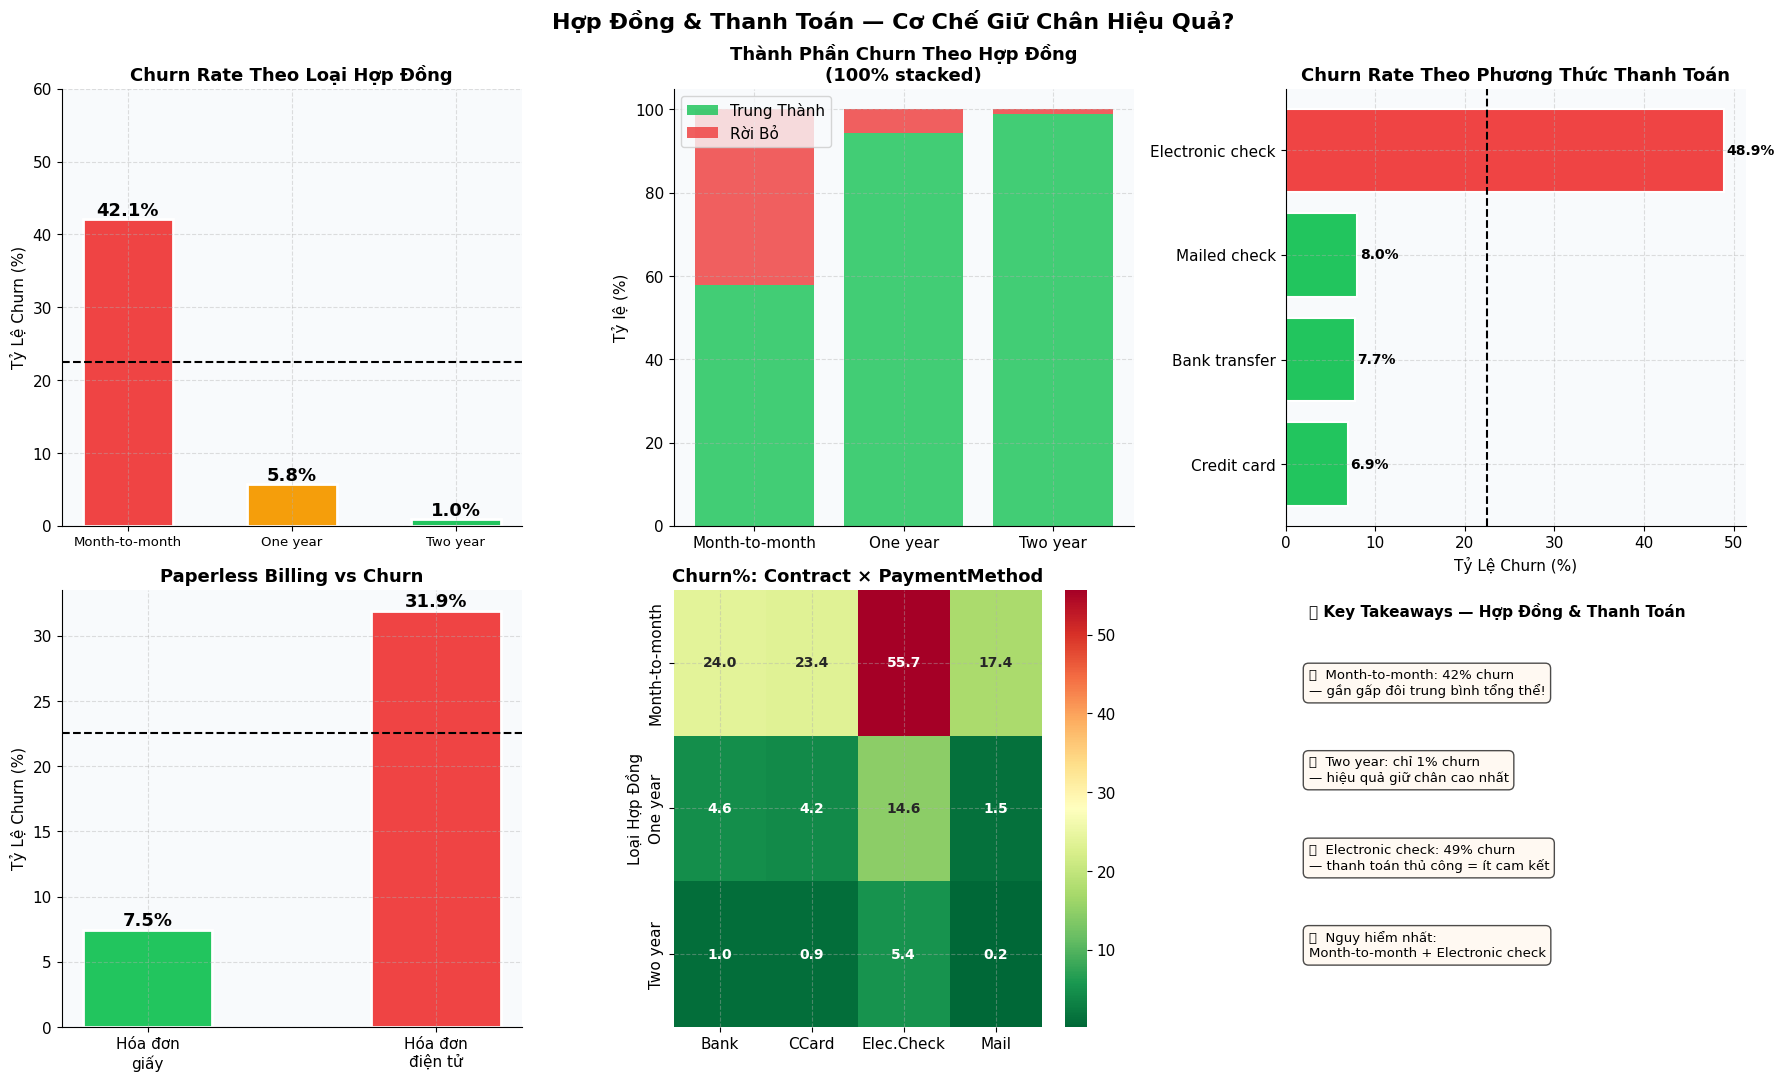

✅ Phần 5 hoàn thành!


In [11]:
# ════════════════════════════════════════════════════════
# PHẦN 5: Hợp đồng & phương thức thanh toán
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Hợp Đồng & Thanh Toán — Cơ Chế Giữ Chân Hiệu Quả?',
             fontsize=16, fontweight='bold')

# 1. Churn by Contract
ax = axes[0, 0]
cr_c = df.groupby('Contract')['Churn'].mean()*100
order_c = ['Month-to-month','One year','Two year']
vals_c = [cr_c[k] for k in order_c]
bars = ax.bar(order_c, vals_c, color=[CHURN_COLOR, PALETTE['accent'], RETAIN_COLOR],
              edgecolor='white', linewidth=2, width=0.55)
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)
ax.set_ylabel('Tỷ Lệ Churn (%)'); ax.set_ylim(0, 60)
ax.set_title('Churn Rate Theo Loại Hợp Đồng', fontweight='bold')
ax.set_xticklabels(['Month-to-month','One year','Two year'], fontsize=9.5)
for bar, val in zip(bars, vals_c):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%',
            ha='center', fontsize=13, fontweight='bold')

# 2. Stacked bar Contract × Churn
ax = axes[0, 1]
cc = pd.crosstab(df['Contract'], df['Churn'])
cc_pct = cc.div(cc.sum(axis=1), axis=0)*100
ax.bar(cc_pct.index, cc_pct[0], label='Trung Thành', color=RETAIN_COLOR, alpha=0.85)
ax.bar(cc_pct.index, cc_pct[1], bottom=cc_pct[0], label='Rời Bỏ', color=CHURN_COLOR, alpha=0.85)
ax.set_ylabel('Tỷ lệ (%)'); ax.legend()
ax.set_title('Thành Phần Churn Theo Hợp Đồng\n(100% stacked)', fontweight='bold')

# 3. PaymentMethod
ax = axes[0, 2]
cr_pay = df.groupby('PaymentMethod')['Churn'].mean()*100
cr_pay = cr_pay.sort_values(ascending=True)
plbls = {
    'Electronic check':'Electronic check','Mailed check':'Mailed check',
    'Bank transfer (automatic)':'Bank transfer','Credit card (automatic)':'Credit card'
}
ylab = [plbls.get(v,v) for v in cr_pay.index]
bc = [CHURN_COLOR if v>30 else RETAIN_COLOR for v in cr_pay.values]
bars = ax.barh(ylab, cr_pay.values, color=bc, edgecolor='white', linewidth=1.5)
ax.axvline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)
ax.set_xlabel('Tỷ Lệ Churn (%)')
ax.set_title('Churn Rate Theo Phương Thức Thanh Toán', fontweight='bold')
for bar, val in zip(bars, cr_pay.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# 4. PaperlessBilling
ax = axes[1, 0]
pb = df.groupby('PaperlessBilling')['Churn'].mean()*100
xlbls = {0:'Hóa đơn\ngiấy', 1:'Hóa đơn\nđiện tử'}
xv = [xlbls[k] for k in pb.index]
bc2 = [CHURN_COLOR if v>28 else RETAIN_COLOR for v in pb.values]
bars = ax.bar(xv, pb.values, color=bc2, width=0.45, edgecolor='white', linewidth=2)
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)
ax.set_ylabel('Tỷ Lệ Churn (%)')
ax.set_title('Paperless Billing vs Churn', fontweight='bold')
for bar, val in zip(bars, pb.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
            ha='center', fontsize=13, fontweight='bold')

# 5. Contract × PaymentMethod heatmap
ax = axes[1, 1]
pivot_cp = df.pivot_table(values='Churn', index='Contract',
                           columns='PaymentMethod', aggfunc='mean')*100
pabrv = {'Electronic check':'Elec.Check','Mailed check':'Mail',
          'Bank transfer (automatic)':'Bank','Credit card (automatic)':'CCard'}
pivot_cp.columns = [pabrv.get(c,c) for c in pivot_cp.columns]
sns.heatmap(pivot_cp, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, annot_kws={'size':10,'weight':'bold'})
ax.set_title('Churn%: Contract × PaymentMethod', fontweight='bold')
ax.set_ylabel('Loại Hợp Đồng'); ax.set_xlabel('')

# 6. Insight
ax = axes[1, 2]
ax.axis('off')
ax.text(0.05, 0.97, "💡 Key Takeaways — Hợp Đồng & Thanh Toán",
        fontsize=11, fontweight='bold', transform=ax.transAxes, va='top')
m2m_rate  = df[df['Contract']=='Month-to-month']['Churn'].mean()*100
tyr_rate  = df[df['Contract']=='Two year']['Churn'].mean()*100
elec_rate = df[df['PaymentMethod']=='Electronic check']['Churn'].mean()*100
ins5 = [
    ("🔴", f"Month-to-month: {m2m_rate:.0f}% churn\n— gần gấp đôi trung bình tổng thể!"),
    ("🟢", f"Two year: chỉ {tyr_rate:.0f}% churn\n— hiệu quả giữ chân cao nhất"),
    ("🟡", f"Electronic check: {elec_rate:.0f}% churn\n— thanh toán thủ công = ít cam kết"),
    ("🔵", "Nguy hiểm nhất:\nMonth-to-month + Electronic check"),
]
y5 = 0.82
for icon, text in ins5:
    ax.text(0.05, y5, f"{icon}  {text}", fontsize=9.5,
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff7ed', alpha=0.7))
    y5 -= 0.20

plt.tight_layout()
plt.savefig('part5_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phần 5 hoàn thành!")


---
## Phần 6 · Danh Mục Dịch Vụ

> **Câu hỏi:** Dịch vụ nào giữ chân? Fiber optic tốt hơn DSL nhưng tại sao churn lại cao hơn?

**Giả thuyết:** Fiber optic = kỳ vọng cao hơn → dễ thất vọng hơn. Dịch vụ bảo mật/hỗ trợ tạo switching cost.


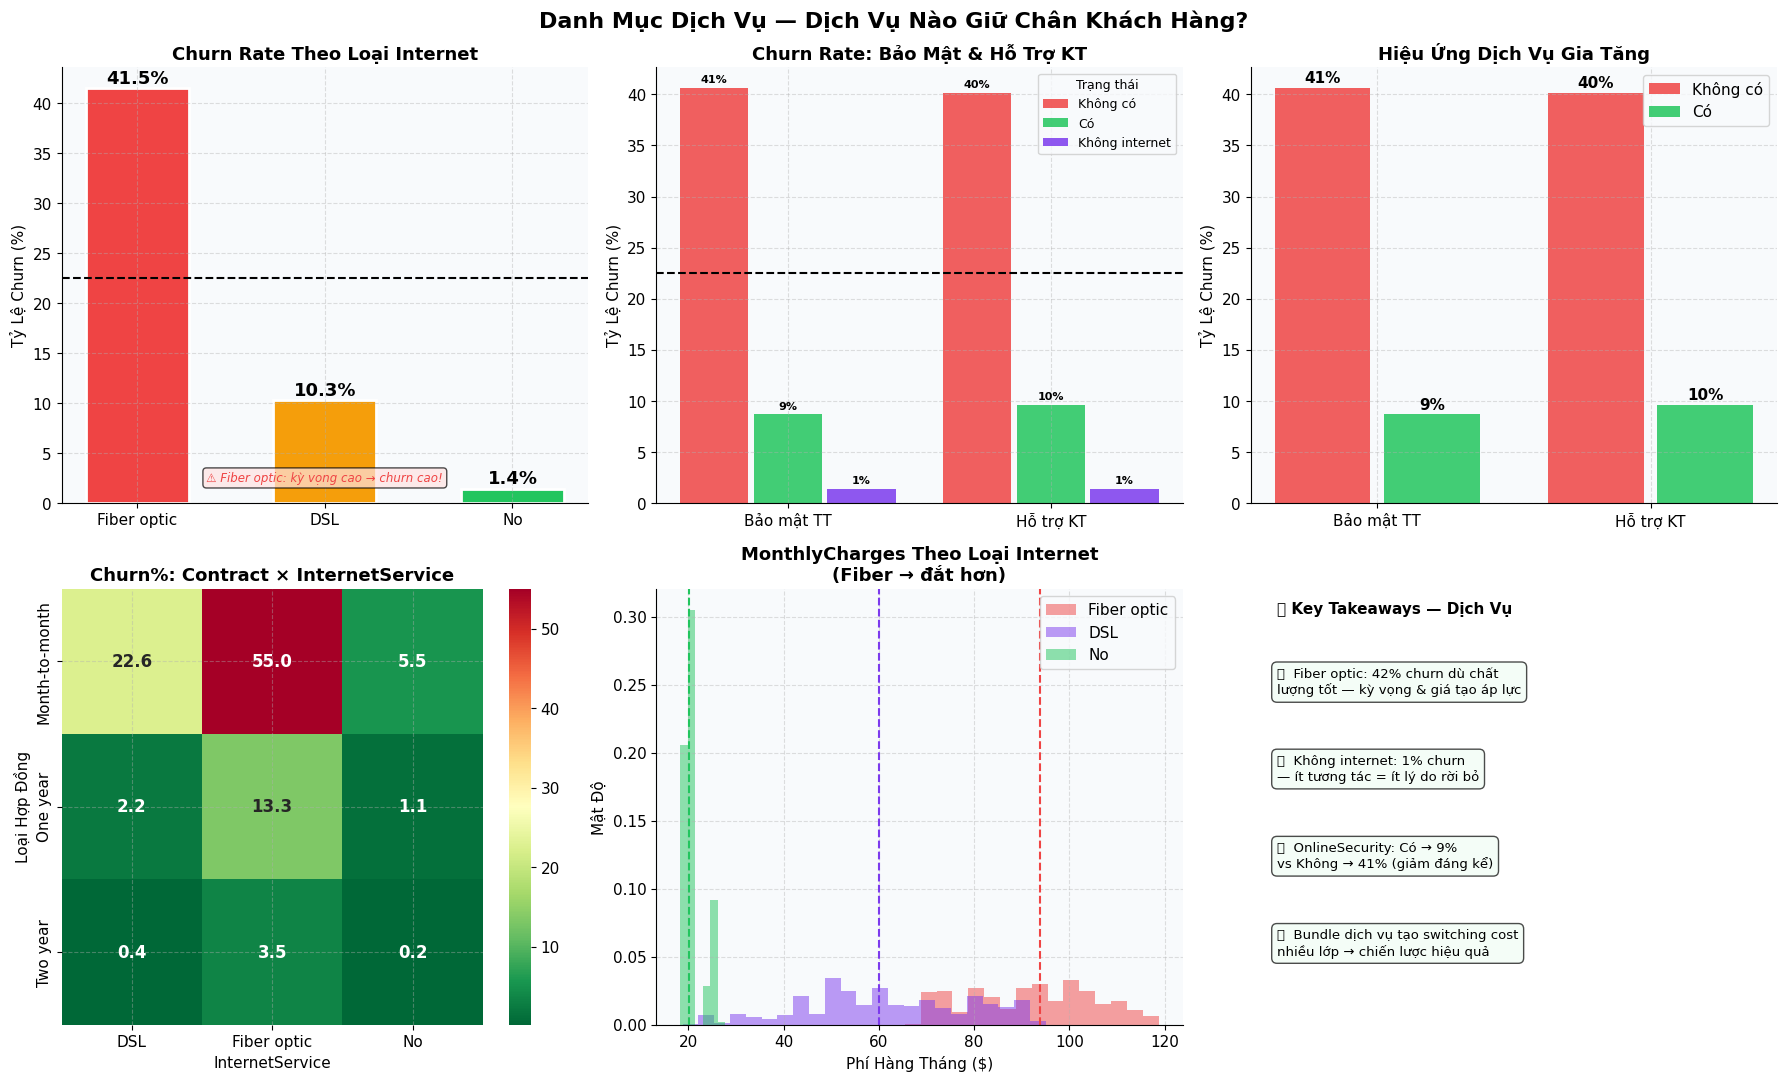

✅ Phần 6 hoàn thành!


In [12]:
# ════════════════════════════════════════════════════════
# PHẦN 6: Danh mục dịch vụ
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Danh Mục Dịch Vụ — Dịch Vụ Nào Giữ Chân Khách Hàng?',
             fontsize=16, fontweight='bold')

# 1. InternetService
ax = axes[0, 0]
cr_inet = df.groupby('InternetService')['Churn'].mean()*100
ord_i = ['Fiber optic','DSL','No']
vals_i = [cr_inet[k] for k in ord_i]
bars = ax.bar(ord_i, vals_i, color=[CHURN_COLOR, PALETTE['accent'], RETAIN_COLOR],
              edgecolor='white', linewidth=2, width=0.55)
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)
ax.set_ylabel('Tỷ Lệ Churn (%)'); ax.set_title('Churn Rate Theo Loại Internet', fontweight='bold')
for bar, val in zip(bars, vals_i):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%',
            ha='center', fontsize=13, fontweight='bold')
ax.text(0.5, 0.05, '⚠️ Fiber optic: kỳ vọng cao → churn cao!',
        transform=ax.transAxes, ha='center', fontsize=8.5, color=CHURN_COLOR,
        style='italic', bbox=dict(boxstyle='round', facecolor='#fee2e2', alpha=0.7))

# 2. OnlineSecurity & TechSupport
ax = axes[0, 1]
svcs = {'OnlineSecurity':'Bảo mật TT', 'TechSupport':'Hỗ trợ KT'}
slbls = ['Không có','Có','Không internet']
scolors = [CHURN_COLOR, RETAIN_COLOR, PALETTE['primary']]
offsets = [-0.28, 0, 0.28]
for i, (col, lbl) in enumerate(svcs.items()):
    cr_s = df.groupby(col)['Churn'].mean()*100
    ord_s = ['No','Yes','No internet service']
    vals_s = [cr_s.get(k,0) for k in ord_s]
    for j, (val, color) in enumerate(zip(vals_s, scolors)):
        bar = ax.bar(i+offsets[j], val, 0.26, color=color, alpha=0.85,
                     label=slbls[j] if i==0 else '')
        ax.text(i+offsets[j], val+0.5, f'{val:.0f}%',
                ha='center', fontsize=8, fontweight='bold')
ax.set_xticks([0,1]); ax.set_xticklabels(list(svcs.values()))
ax.set_ylabel('Tỷ Lệ Churn (%)')
ax.set_title('Churn Rate: Bảo Mật & Hỗ Trợ KT', fontweight='bold')
ax.legend(title='Trạng thái', fontsize=9, title_fontsize=9)
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1.5)

# 3. Có vs Không dịch vụ
ax = axes[0, 2]
svc_impact = {}
for col, lbl in svcs.items():
    svc_impact[lbl] = {
        'Có dịch vụ': df[df[col]=='Yes']['Churn'].mean()*100,
        'Không có':   df[df[col]=='No']['Churn'].mean()*100,
    }
x3 = np.arange(len(svc_impact)); lbls3 = list(svc_impact.keys())
no_vals  = [v['Không có']   for v in svc_impact.values()]
yes_vals = [v['Có dịch vụ'] for v in svc_impact.values()]
b1 = ax.bar(x3-0.2, no_vals,  0.35, label='Không có', color=CHURN_COLOR,  alpha=0.85)
b2 = ax.bar(x3+0.2, yes_vals, 0.35, label='Có',       color=RETAIN_COLOR, alpha=0.85)
ax.set_xticks(x3); ax.set_xticklabels(lbls3)
ax.set_ylabel('Tỷ Lệ Churn (%)'); ax.legend()
ax.set_title('Hiệu Ứng Dịch Vụ Gia Tăng', fontweight='bold')
for bars, vals in [(b1,no_vals),(b2,yes_vals)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%',
                ha='center', fontsize=11, fontweight='bold')

# 4. Contract × InternetService heatmap
ax = axes[1, 0]
pivot_ci = df.pivot_table(values='Churn', index='Contract',
                           columns='InternetService', aggfunc='mean')*100
sns.heatmap(pivot_ci, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, annot_kws={'size':12,'weight':'bold'})
ax.set_title('Churn%: Contract × InternetService', fontweight='bold')
ax.set_ylabel('Loại Hợp Đồng')

# 5. MonthlyCharges by Internet
ax = axes[1, 1]
for it, color in [('Fiber optic',CHURN_COLOR),('DSL',PALETTE['primary']),('No',RETAIN_COLOR)]:
    sub = df[df['InternetService']==it]['MonthlyCharges']
    ax.hist(sub, bins=30, density=True, alpha=0.5, color=color, label=it)
    ax.axvline(sub.median(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('Phí Hàng Tháng ($)'); ax.set_ylabel('Mật Độ')
ax.set_title('MonthlyCharges Theo Loại Internet\n(Fiber → đắt hơn)', fontweight='bold')
ax.legend()

# 6. Insights
ax = axes[1, 2]
ax.axis('off')
ax.text(0.05,0.97,"💡 Key Takeaways — Dịch Vụ",
        fontsize=11, fontweight='bold', transform=ax.transAxes, va='top')
fiber_rate   = df[df['InternetService']=='Fiber optic']['Churn'].mean()*100
no_inet_rate = df[df['InternetService']=='No']['Churn'].mean()*100
sec_y = df[df['OnlineSecurity']=='Yes']['Churn'].mean()*100
sec_n = df[df['OnlineSecurity']=='No']['Churn'].mean()*100
ins6 = [
    ("🔴", f"Fiber optic: {fiber_rate:.0f}% churn dù chất\nlượng tốt — kỳ vọng & giá tạo áp lực"),
    ("🟢", f"Không internet: {no_inet_rate:.0f}% churn\n— ít tương tác = ít lý do rời bỏ"),
    ("🟢", f"OnlineSecurity: Có → {sec_y:.0f}%\nvs Không → {sec_n:.0f}% (giảm đáng kể)"),
    ("🔵", "Bundle dịch vụ tạo switching cost\nnhiều lớp → chiến lược hiệu quả"),
]
y6 = 0.82
for icon, text in ins6:
    ax.text(0.05,y6,f"{icon}  {text}",fontsize=9.5,transform=ax.transAxes,va='top',
            bbox=dict(boxstyle='round,pad=0.4',facecolor='#f0fdf4',alpha=0.7))
    y6 -= 0.20

plt.tight_layout()
plt.savefig('part6_services.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phần 6 hoàn thành!")


---
## Phần 7 · Tương Tác Đặc Trưng (N-gram Insights)

> **Câu hỏi:** Các yếu tố kết hợp như thế nào? Đây là lý do model gốc dùng Bi-gram/Tri-gram encoding.

**Insight:** Không yếu tố đơn lẻ nào giải thích toàn bộ churn — sức mạnh nằm ở **tổ hợp**.


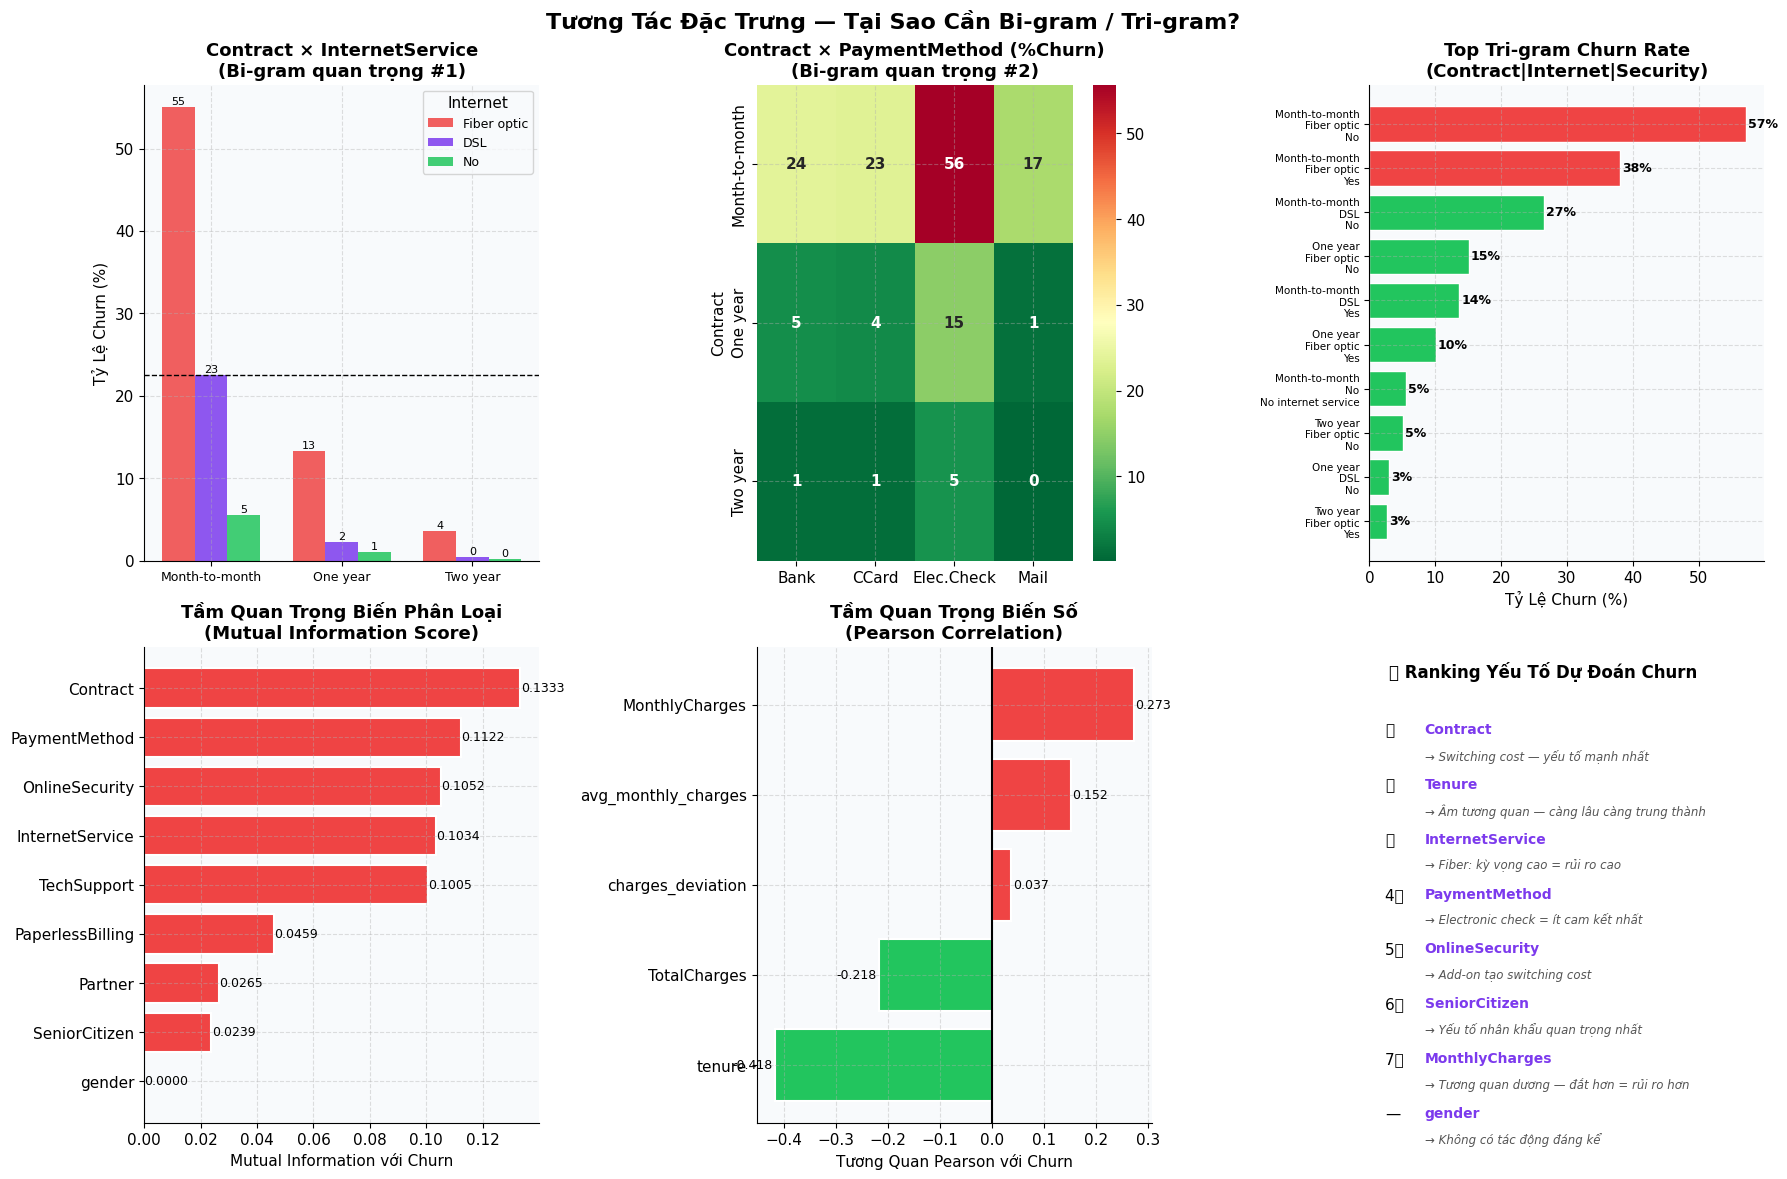

✅ Phần 7 hoàn thành!


In [13]:
# ════════════════════════════════════════════════════════
# PHẦN 7: Tương tác đặc trưng — Bi/Tri-gram Insights
# ════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Tương Tác Đặc Trưng — Tại Sao Cần Bi-gram / Tri-gram?',
             fontsize=16, fontweight='bold')

# 1. Contract × InternetService bar group
ax = axes[0, 0]
grp = df.groupby(['Contract','InternetService'])['Churn'].mean()*100
grp = grp.reset_index().pivot(index='Contract', columns='InternetService', values='Churn')
grp = grp[['Fiber optic','DSL','No']]
x7 = np.arange(len(grp.index)); w7 = 0.25
for i,(col,color) in enumerate(zip(grp.columns,[CHURN_COLOR,PALETTE['primary'],RETAIN_COLOR])):
    bars = ax.bar(x7+(i-1)*w7, grp[col], w7, label=col, color=color, alpha=0.85)
    for bar, val in zip(bars, grp[col]):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.0f}',
                ha='center', fontsize=8)
ax.set_xticks(x7); ax.set_xticklabels(grp.index, fontsize=9)
ax.set_ylabel('Tỷ Lệ Churn (%)'); ax.legend(title='Internet',fontsize=9)
ax.set_title('Contract × InternetService\n(Bi-gram quan trọng #1)', fontweight='bold')
ax.axhline(df['Churn'].mean()*100, linestyle='--', color='black', linewidth=1)

# 2. Contract × PaymentMethod heatmap
ax = axes[0, 1]
grp2 = df.groupby(['Contract','PaymentMethod'])['Churn'].mean()*100
grp2_p = grp2.reset_index().pivot(index='Contract',columns='PaymentMethod',values='Churn')
pabrv2 = {'Electronic check':'Elec.Check','Mailed check':'Mail',
           'Bank transfer (automatic)':'Bank','Credit card (automatic)':'CCard'}
grp2_p.columns = [pabrv2.get(c,c) for c in grp2_p.columns]
sns.heatmap(grp2_p, annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, annot_kws={'size':11,'weight':'bold'})
ax.set_title('Contract × PaymentMethod (%Churn)\n(Bi-gram quan trọng #2)', fontweight='bold')

# 3. Tri-gram top churn rates
ax = axes[0, 2]
df['trigram'] = (df['Contract'].astype(str)+'|'+
                  df['InternetService'].astype(str)+'|'+
                  df['OnlineSecurity'].astype(str))
tri_top = (df.groupby('trigram')['Churn']
             .agg(['mean','count']).query('count>200')
             .sort_values('mean',ascending=True).tail(10))
tri_top['rate'] = tri_top['mean']*100
bc_tri = [CHURN_COLOR if v>35 else RETAIN_COLOR for v in tri_top['rate']]
ax.barh(range(len(tri_top)), tri_top['rate'], color=bc_tri, edgecolor='white', linewidth=1)
ax.set_yticks(range(len(tri_top)))
ax.set_yticklabels([t.replace('|','\n') for t in tri_top.index], fontsize=7.5)
ax.set_xlabel('Tỷ Lệ Churn (%)')
ax.set_title('Top Tri-gram Churn Rate\n(Contract|Internet|Security)', fontweight='bold')
for i, val in enumerate(tri_top['rate']):
    ax.text(val+0.3, i, f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')

# 4. Mutual Information
ax = axes[1, 0]
cat_cols_mi = ['Contract','InternetService','PaymentMethod',
               'OnlineSecurity','TechSupport','PaperlessBilling',
               'SeniorCitizen','Partner','gender']
mi_vals = {c: mutual_info_score(df[c], df['Churn']) for c in cat_cols_mi}
mi_s = pd.Series(mi_vals).sort_values(ascending=True)
bc_mi = [CHURN_COLOR if v>0.015 else PALETTE['accent'] if v>0.005 else RETAIN_COLOR
         for v in mi_s.values]
bars = ax.barh(mi_s.index, mi_s.values, color=bc_mi, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Mutual Information với Churn')
ax.set_title('Tầm Quan Trọng Biến Phân Loại\n(Mutual Information Score)', fontweight='bold')
for bar, val in zip(bars, mi_s.values):
    ax.text(val+0.0001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# 5. Pearson correlation (numeric)
ax = axes[1, 1]
num_corr = df[['tenure','MonthlyCharges','TotalCharges',
               'charges_deviation','avg_monthly_charges']].corrwith(df['Churn'])
num_corr = num_corr.sort_values()
bc_nc = [CHURN_COLOR if v>0 else RETAIN_COLOR for v in num_corr.values]
bars = ax.barh(num_corr.index, num_corr.values, color=bc_nc, edgecolor='white', linewidth=1.5)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Tương Quan Pearson với Churn')
ax.set_title('Tầm Quan Trọng Biến Số\n(Pearson Correlation)', fontweight='bold')
for bar, val in zip(bars, num_corr.values):
    xoff = 0.003 if val>0 else -0.003
    ax.text(val+xoff, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9,
            ha='left' if val>0 else 'right')

# 6. Summary ranking
ax = axes[1, 2]
ax.axis('off')
ax.text(0.05,0.97,"🏆 Ranking Yếu Tố Dự Đoán Churn",
        fontsize=12,fontweight='bold',transform=ax.transAxes,va='top')
preds = [
    ("🥇","Contract",        "Switching cost — yếu tố mạnh nhất"),
    ("🥈","Tenure",           "Âm tương quan — càng lâu càng trung thành"),
    ("🥉","InternetService",  "Fiber: kỳ vọng cao = rủi ro cao"),
    ("4️⃣","PaymentMethod",   "Electronic check = ít cam kết nhất"),
    ("5️⃣","OnlineSecurity",  "Add-on tạo switching cost"),
    ("6️⃣","SeniorCitizen",   "Yếu tố nhân khẩu quan trọng nhất"),
    ("7️⃣","MonthlyCharges",  "Tương quan dương — đắt hơn = rủi ro hơn"),
    ("—", "gender",           "Không có tác động đáng kể"),
]
y7 = 0.84
for rank, name, desc in preds:
    ax.text(0.04,y7,rank,fontsize=11,transform=ax.transAxes,va='top')
    ax.text(0.14,y7,name,fontsize=10,fontweight='bold',
            transform=ax.transAxes,va='top',color=PALETTE['primary'])
    ax.text(0.14,y7-0.055,f"→ {desc}",fontsize=8.5,style='italic',
            transform=ax.transAxes,va='top',color='#555')
    y7 -= 0.115

plt.tight_layout()
plt.savefig('part7_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phần 7 hoàn thành!")


---
## Phần 8 · Dashboard Tổng Hợp & Kết Luận

> **Tổng hợp toàn bộ hành trình phân tích thành các insight có thể hành động được.**


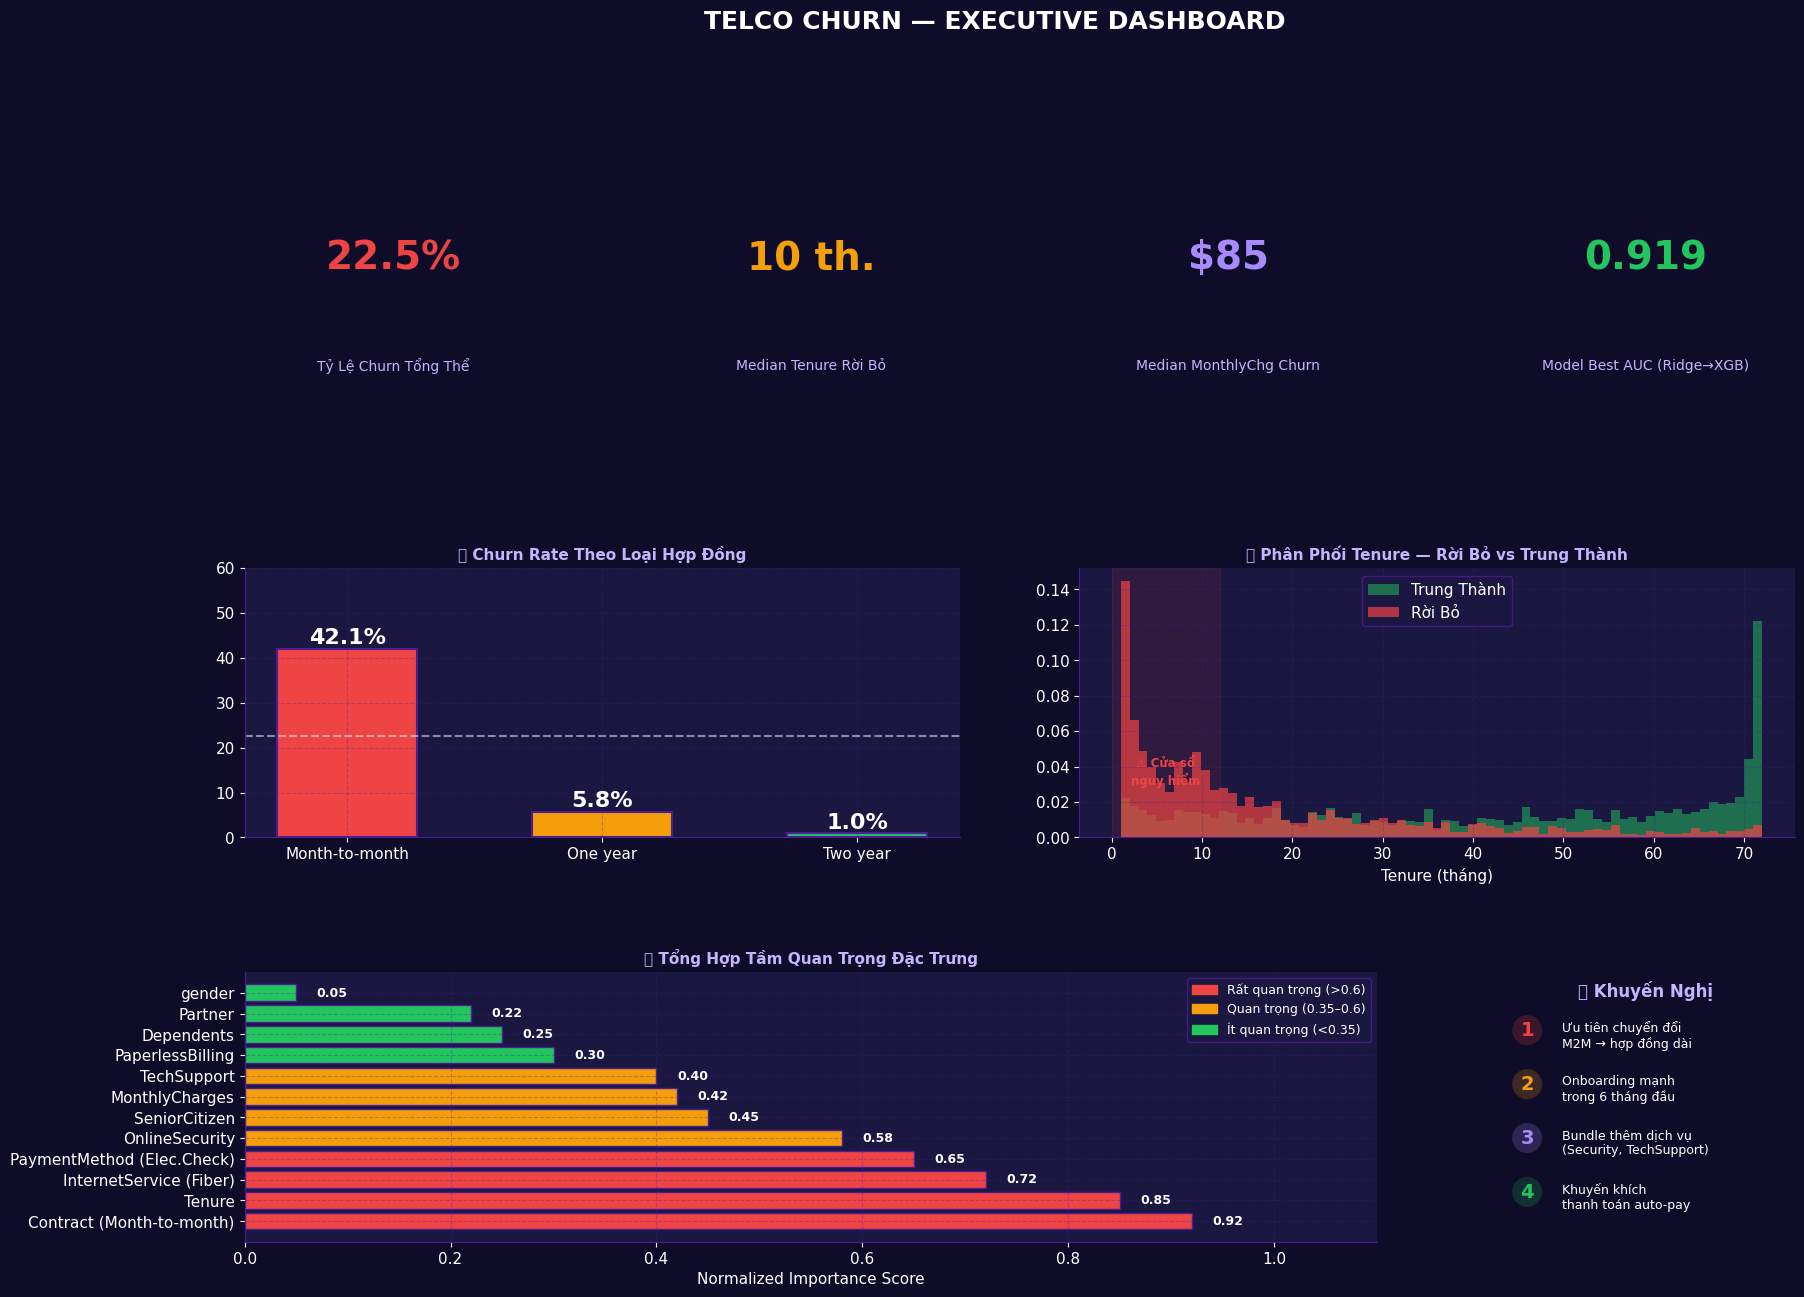

✅ Phần 8 — Dashboard hoàn thành!


In [14]:
# ════════════════════════════════════════════════════════
# PHẦN 8: Executive Dashboard
# ════════════════════════════════════════════════════════

def dark_ax(ax, title=''):
    ax.set_facecolor('#1a1740')
    for s in ax.spines.values():
        s.set_edgecolor('#4c1d95')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    if title:
        ax.set_title(title, color='#c4b5fd', fontweight='bold', fontsize=11)
    ax.grid(color='#4c1d95', alpha=0.3, linestyle='--')

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f0c29')
gs8 = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# KPI Cards — tính động từ dữ liệu thật
_churn_rate   = df["Churn"].mean() * 100
_med_tenure   = churn_df["tenure"].median()
_med_mc       = churn_df["MonthlyCharges"].median()
kpis = [
    (f"{_churn_rate:.1f}%",  "Tỷ Lệ Churn Tổng Thể",     "#ef4444"),
    (f"{_med_tenure:.0f} th.", "Median Tenure Rời Bỏ",     "#f59e0b"),
    (f"${_med_mc:.0f}",      "Median MonthlyChg Churn",    "#a78bfa"),
    ("0.919",                "Model Best AUC (Ridge→XGB)", "#22c55e"),
]
for i, (val, lbl, color) in enumerate(kpis):
    ax = fig.add_subplot(gs8[0, i])
    ax.set_facecolor('#1a1740'); ax.axis('off')
    ax.text(0.5,0.65,val, ha='center',va='center',fontsize=28,
            fontweight='black',color=color,transform=ax.transAxes)
    ax.text(0.5,0.25,lbl, ha='center',va='center',fontsize=10,
            color='#c4b5fd',transform=ax.transAxes)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2)

# Churn by Contract
ax = fig.add_subplot(gs8[1, :2])
dark_ax(ax, '📋 Churn Rate Theo Loại Hợp Đồng')
cr_c8 = df.groupby('Contract')['Churn'].mean()*100
ord8  = ['Month-to-month','One year','Two year']
v8    = [cr_c8[k] for k in ord8]
bars  = ax.bar(ord8, v8, color=['#ef4444','#f59e0b','#22c55e'],
               edgecolor='#4c1d95', linewidth=1.5, width=0.55)
ax.axhline(df['Churn'].mean()*100, color='white', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_ylim(0,60)
for bar, val in zip(bars, v8):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}%',
            ha='center', fontsize=16, fontweight='bold', color='white')

# Tenure distribution
ax = fig.add_subplot(gs8[1, 2:])
dark_ax(ax, '⏱️ Phân Phối Tenure — Rời Bỏ vs Trung Thành')
ax.hist(retain_df['tenure'], bins=72, density=True, alpha=0.5,
        color='#22c55e', label='Trung Thành')
ax.hist(churn_df['tenure'],  bins=72, density=True, alpha=0.7,
        color='#ef4444', label='Rời Bỏ')
ax.axvspan(0,12, alpha=0.1, color='#ef4444')
ax.text(6, 0.03, '⚠️ Cửa sổ\nnguy hiểm', ha='center',
        color='#ef4444', fontsize=8.5, fontweight='bold')
ax.legend(facecolor='#1a1740', edgecolor='#4c1d95', labelcolor='white')
ax.set_xlabel('Tenure (tháng)', color='white')

# Feature importance
ax = fig.add_subplot(gs8[2, :3])
dark_ax(ax, '🏆 Tổng Hợp Tầm Quan Trọng Đặc Trưng')
feats = {
    'Contract (Month-to-month)':   0.92,
    'Tenure':                       0.85,
    'InternetService (Fiber)':      0.72,
    'PaymentMethod (Elec.Check)':   0.65,
    'OnlineSecurity':               0.58,
    'SeniorCitizen':                0.45,
    'MonthlyCharges':               0.42,
    'TechSupport':                  0.40,
    'PaperlessBilling':             0.30,
    'Dependents':                   0.25,
    'Partner':                      0.22,
    'gender':                       0.05,
}
fn = list(feats.keys()); fv = list(feats.values())
fc = ['#ef4444' if v>0.6 else '#f59e0b' if v>0.35 else '#22c55e' for v in fv]
bars = ax.barh(fn, fv, color=fc, edgecolor='#4c1d95', linewidth=1)
ax.set_xlim(0,1.1); ax.set_xlabel('Normalized Importance Score', color='white')
for bar, val in zip(bars, fv):
    ax.text(val+0.02, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='white', fontweight='bold')
patches_legend = [
    mpatches.Patch(color='#ef4444', label='Rất quan trọng (>0.6)'),
    mpatches.Patch(color='#f59e0b', label='Quan trọng (0.35–0.6)'),
    mpatches.Patch(color='#22c55e', label='Ít quan trọng (<0.35)'),
]
ax.legend(handles=patches_legend, facecolor='#1a1740',
          edgecolor='#4c1d95', labelcolor='white', fontsize=9)

# Action items
ax = fig.add_subplot(gs8[2, 3])
ax.set_facecolor('#1a1740'); ax.axis('off')
ax.text(0.5,0.97,"🎯 Khuyến Nghị", ha='center',va='top',
        fontsize=12,fontweight='bold',color='#c4b5fd',transform=ax.transAxes)
actions = [
    ("1","#ef4444","Ưu tiên chuyển đổi\nM2M → hợp đồng dài"),
    ("2","#f59e0b","Onboarding mạnh\ntrong 6 tháng đầu"),
    ("3","#a78bfa","Bundle thêm dịch vụ\n(Security, TechSupport)"),
    ("4","#22c55e","Khuyến khích\nthanh toán auto-pay"),
]
ya = 0.82
for num, color, text in actions:
    ax.text(0.08,ya,num,fontsize=14,fontweight='black',color=color,
            transform=ax.transAxes,va='top',
            bbox=dict(boxstyle='circle',facecolor=color,alpha=0.2))
    ax.text(0.22,ya,text,fontsize=9,color='white',
            transform=ax.transAxes,va='top')
    ya -= 0.20

fig.suptitle('TELCO CHURN — EXECUTIVE DASHBOARD',
             fontsize=18,fontweight='black',color='white',y=0.99)
plt.savefig('part8_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Phần 8 — Dashboard hoàn thành!")


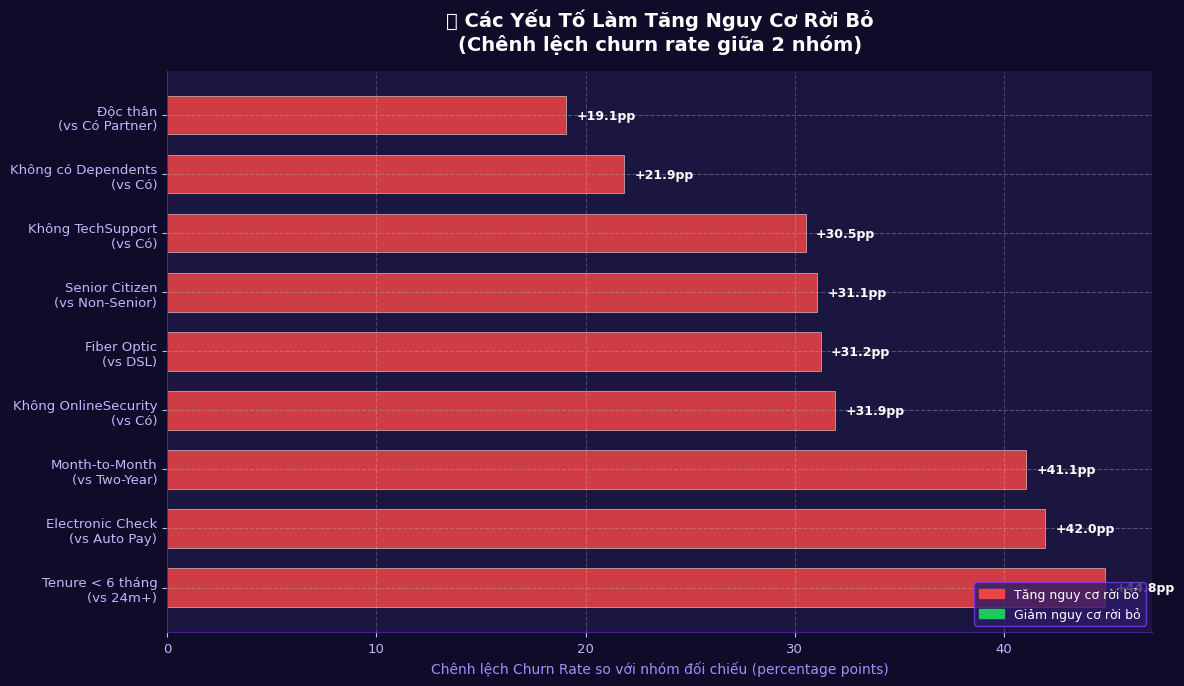

✅ Visual 1 — Ranked Bar Chart hoàn thành!


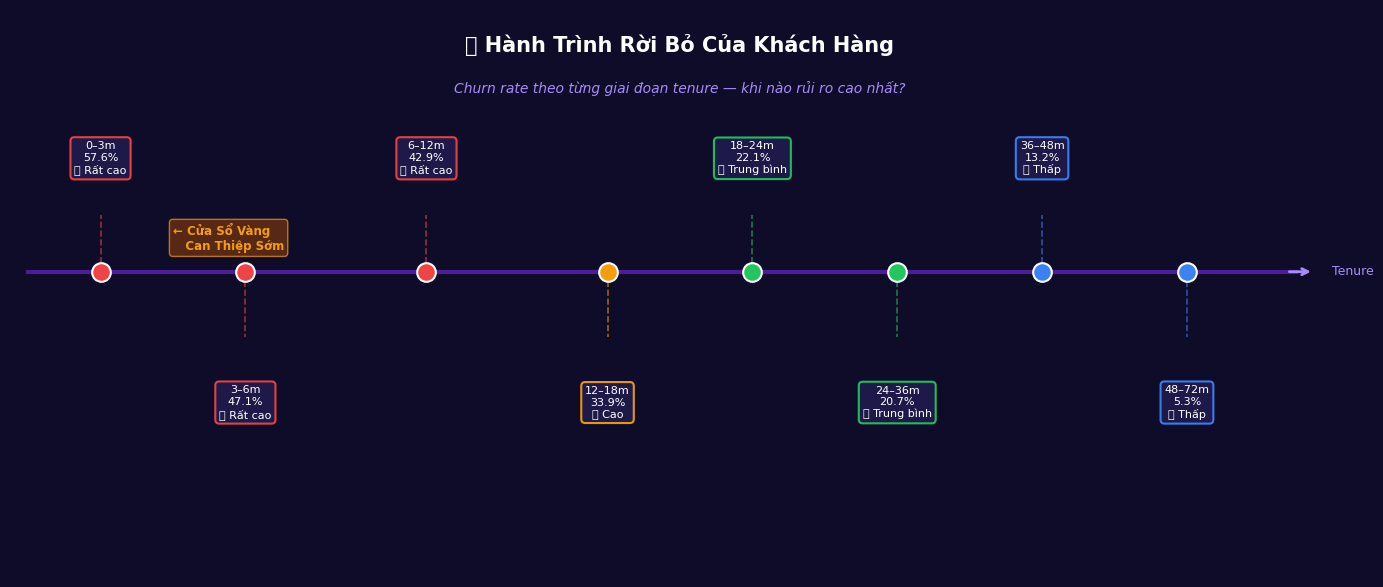

✅ Visual 2 — Customer Journey Timeline hoàn thành!


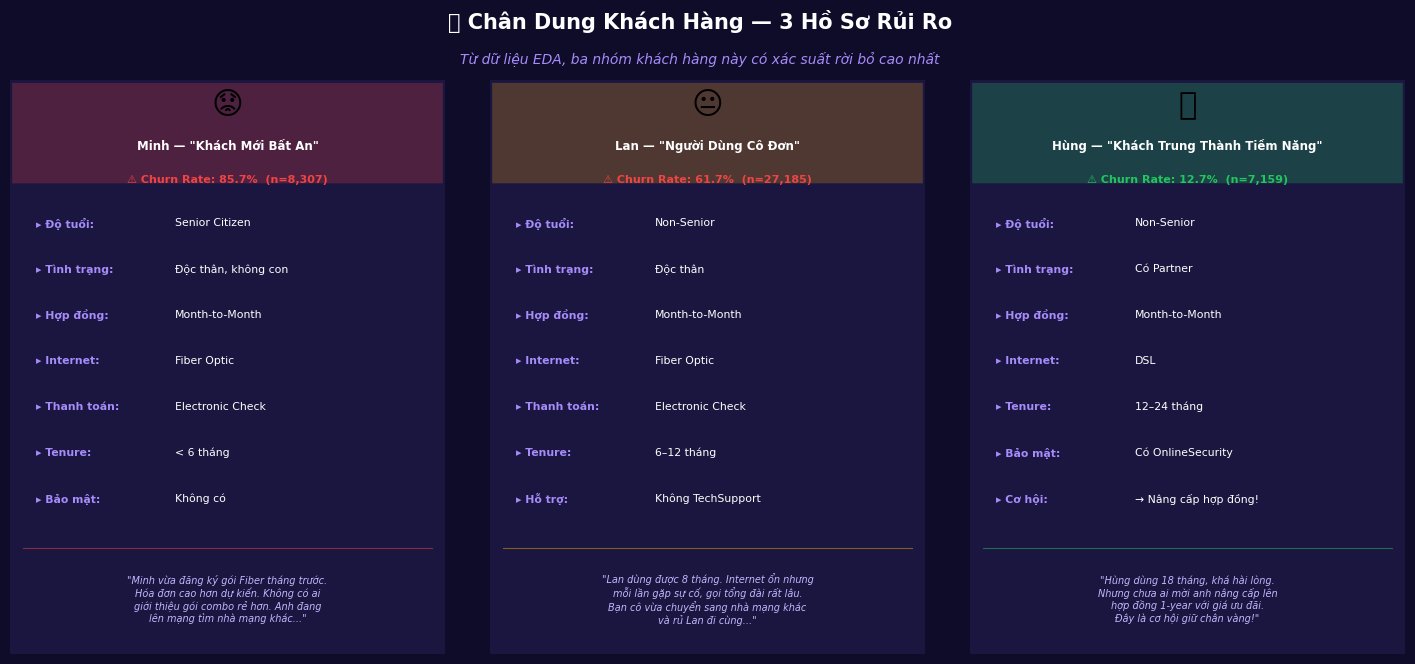

✅ Visual 3 — Persona Cards hoàn thành!


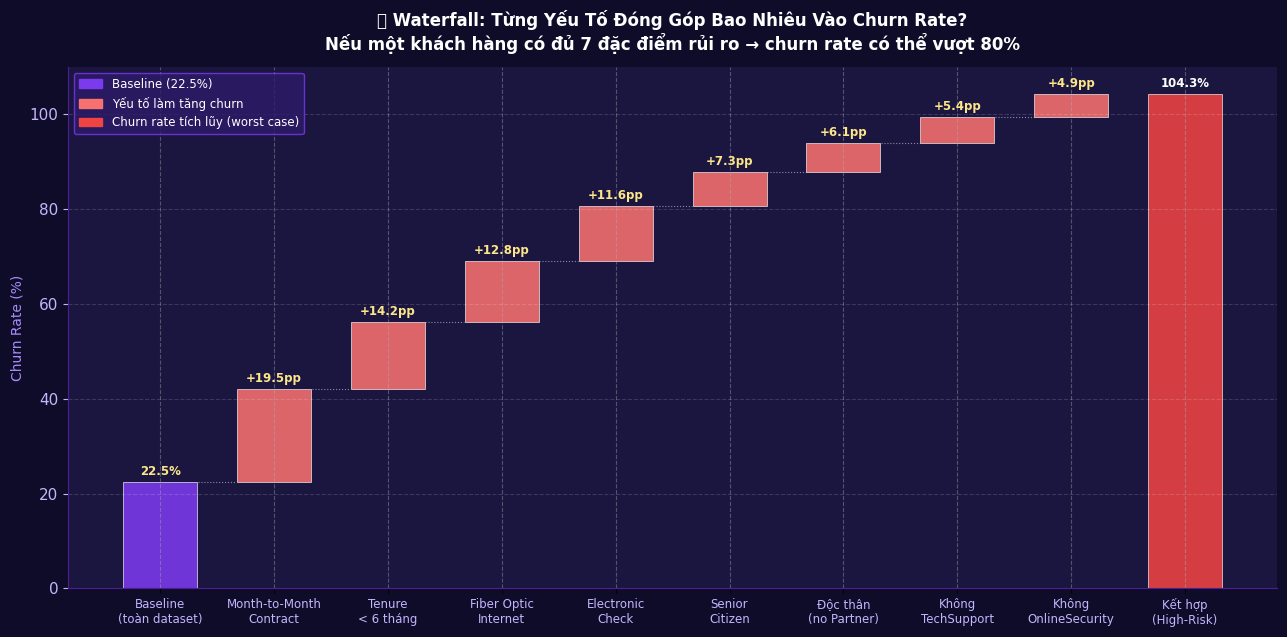

✅ Visual 4 — Waterfall Chart hoàn thành!

╔══════════════════════════════════════════════════════════════════════╗
║        📖 TÓM TẮT PHẦN 7.5 — TẠI SAO KHÁCH HÀNG RỜI BỎ?          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Từ 4 góc nhìn phân tích trên, câu trả lời hội tụ về 3 lý do chính:║
║                                                                      ║
║  🔑 LÝ DO 1 — "Chưa đủ lý do ở lại" (Lock-in yếu)                 ║
║     Month-to-Month = không cam kết = dễ bỏ bất cứ lúc nào.         ║
║     → Giải pháp: incentive chuyển sang 1-year/2-year contract.      ║
║                                                                      ║
║  🔑 LÝ DO 2 — "Giá trị cảm nhận thấp" (Value Perception gap)       ║
║     Tenure ngắn + phí cao = chưa kịp cảm nhận giá trị dịch vụ.    ║
║     Fiber optic kỳ vọng cao → thất vọng nhanh hơn.                 ║
║     → Giải pháp: onboarding c

In [15]:
# ════════════════════════════════════════════════════════════════════════
# PHẦN 7.5 · TẠI SAO KHÁCH HÀNG RỜI BỎ? — Tổng hợp nguyên nhân
# Đặt cell này SAU Phần 7 (Tương tác đặc trưng), TRƯỚC Phần 8 (Dashboard)
# ════════════════════════════════════════════════════════════════════════

# ── [MARKDOWN CELL] ──────────────────────────────────────────────────────
"""
---
## Phần 7.5 · Tại Sao Khách Hàng Rời Bỏ?

> **Câu hỏi trọng tâm:** Sau tất cả các phân tích, đâu là những nguyên nhân
> cốt lõi khiến khách hàng quyết định rời bỏ?

Chúng ta đã khám phá từng góc độ riêng lẻ — nhân khẩu học, hành trình sử dụng,
tài chính, hợp đồng, dịch vụ. Phần này tổng hợp tất cả thành **4 bức tranh**
giải thích trực quan nhất cho câu hỏi cốt lõi của đề tài.

---
"""

# ── [CODE CELL 1] — Visual 1: Ranked Bar Chart các yếu tố ảnh hưởng ──────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    'churn':   '#ef4444',
    'retain':  '#22c55e',
    'primary': '#7c3aed',
    'accent':  '#f59e0b',
    'dark':    '#1e1b4b',
    'light':   '#f8fafc',
}

# ── Tính churn rate theo từng yếu tố nhị phân / phân loại ────────────────

def churn_rate_by(col, df=df):
    return df.groupby(col)['Churn'].mean() * 100

# Tính churn rate differential (so với baseline)
baseline = df['Churn'].mean() * 100

factors = {}

# Contract
cr = churn_rate_by('Contract')
factors['Month-to-Month\n(vs Two-Year)'] = cr.get('Month-to-month', 0) - cr.get('Two year', 0)

# Internet Service
cr = churn_rate_by('InternetService')
factors['Fiber Optic\n(vs DSL)'] = cr.get('Fiber optic', 0) - cr.get('DSL', 0)

# PaymentMethod
cr = churn_rate_by('PaymentMethod')
factors['Electronic Check\n(vs Auto Pay)'] = cr.get('Electronic check', 0) - min(cr.get('Bank transfer (automatic)', 0), cr.get('Credit card (automatic)', 0))

# SeniorCitizen
cr = churn_rate_by('SeniorCitizen')
factors['Senior Citizen\n(vs Non-Senior)'] = cr.get(1, 0) - cr.get(0, 0)

# No TechSupport
cr = churn_rate_by('TechSupport')
factors['Không TechSupport\n(vs Có)'] = cr.get('No', 0) - cr.get('Yes', 0)

# OnlineSecurity
cr = churn_rate_by('OnlineSecurity')
factors['Không OnlineSecurity\n(vs Có)'] = cr.get('No', 0) - cr.get('Yes', 0)

# Partner
cr = churn_rate_by('Partner')
factors['Độc thân\n(vs Có Partner)'] = cr.get(0, 0) - cr.get(1, 0)

# Dependents
cr = churn_rate_by('Dependents')
factors['Không có Dependents\n(vs Có)'] = cr.get(0, 0) - cr.get(1, 0)

# Tenure nhóm
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,6,12,24,72], labels=['0-6m','6-12m','12-24m','24m+'])
cr = churn_rate_by('tenure_group')
factors['Tenure < 6 tháng\n(vs 24m+)'] = cr.get('0-6m', 0) - cr.get('24m+', 0)

# Sắp xếp
factors_sorted = dict(sorted(factors.items(), key=lambda x: x[1], reverse=True))

# ── PLOT ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1640')

labels = list(factors_sorted.keys())
values = list(factors_sorted.values())
colors = [PALETTE['churn'] if v > 0 else PALETTE['retain'] for v in values]

bars = ax.barh(labels, values, color=colors, alpha=0.85, height=0.65,
               edgecolor='white', linewidth=0.4)

# Thêm số liệu
for bar, val in zip(bars, values):
    sign = '+' if val > 0 else ''
    ax.text(val + (0.5 if val > 0 else -0.5), bar.get_y() + bar.get_height()/2,
            f'{sign}{val:.1f}pp', va='center',
            ha='left' if val > 0 else 'right',
            color='white', fontsize=9, fontweight='bold')

ax.axvline(0, color='white', linewidth=1.2, alpha=0.6, linestyle='--')
ax.set_xlabel('Chênh lệch Churn Rate so với nhóm đối chiếu (percentage points)',
              color='#a78bfa', fontsize=10)
ax.set_title('🎯 Các Yếu Tố Làm Tăng Nguy Cơ Rời Bỏ\n(Chênh lệch churn rate giữa 2 nhóm)',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#c4b5fd', labelsize=9.5)
ax.spines['bottom'].set_color('#4c1d95')
ax.spines['left'].set_color('#4c1d95')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, color='white', linestyle='--')

# Legend
red_patch = mpatches.Patch(color=PALETTE['churn'], label='Tăng nguy cơ rời bỏ')
green_patch = mpatches.Patch(color=PALETTE['retain'], label='Giảm nguy cơ rời bỏ')
ax.legend(handles=[red_patch, green_patch], loc='lower right',
          facecolor='#2d1b69', edgecolor='#7c3aed', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('visual1_ranked_factors.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0c29')
plt.show()
print("✅ Visual 1 — Ranked Bar Chart hoàn thành!")


# ── [CODE CELL 2] — Visual 2: Customer Journey / Timeline rời bỏ ─────────

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#0f0c29')
ax.set_xlim(-1, 73)
ax.set_ylim(-2.5, 4)
ax.axis('off')

# Title
ax.text(36, 3.6, '⏱️ Hành Trình Rời Bỏ Của Khách Hàng',
        ha='center', va='center', fontsize=15, fontweight='bold', color='white')
ax.text(36, 3.1, 'Churn rate theo từng giai đoạn tenure — khi nào rủi ro cao nhất?',
        ha='center', va='center', fontsize=10, color='#a78bfa', style='italic')

# Tính churn rate theo tenure bins
tenure_bins  = [0, 3, 6, 12, 18, 24, 36, 48, 72]
tenure_lbls  = ['0–3m', '3–6m', '6–12m', '12–18m', '18–24m', '24–36m', '36–48m', '48–72m']
df['t_bin']  = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_lbls)
churn_by_t   = df.groupby('t_bin', observed=True)['Churn'].mean() * 100

# Timeline x-positions
x_pos = [4, 12, 22, 32, 40, 48, 56, 64]
y_base = 1.0

# Đường timeline
ax.plot([0, 70], [y_base, y_base], color='#4c1d95', linewidth=3, zorder=1)

# Màu sắc theo mức độ rủi ro
def risk_color(rate):
    if rate >= 40: return '#ef4444'
    elif rate >= 25: return '#f59e0b'
    elif rate >= 15: return '#22c55e'
    else: return '#3b82f6'

def risk_label(rate):
    if rate >= 40: return '🔴 Rất cao'
    elif rate >= 25: return '🟡 Cao'
    elif rate >= 15: return '🟢 Trung bình'
    else: return '🔵 Thấp'

for i, (lbl, xp) in enumerate(zip(tenure_lbls, x_pos)):
    rate = churn_by_t.get(lbl, 0)
    col  = risk_color(rate)

    # Dot trên timeline
    ax.scatter(xp, y_base, s=180, color=col, zorder=5, edgecolors='white', linewidth=1.5)

    # Alternating up/down
    y_text = y_base + 1.3 if i % 2 == 0 else y_base - 1.5
    y_mid  = y_base + 0.65 if i % 2 == 0 else y_base - 0.75
    ax.plot([xp, xp], [y_base, y_mid], color=col, linewidth=1.2, linestyle='--', alpha=0.6)

    # Box
    bbox_props = dict(boxstyle='round,pad=0.35', facecolor='#1e1b4b', edgecolor=col,
                      linewidth=1.5, alpha=0.95)
    ax.text(xp, y_text, f'{lbl}\n{rate:.1f}%\n{risk_label(rate)}',
            ha='center', va='center', fontsize=8, color='white',
            bbox=bbox_props, multialignment='center')

# Arrow đầu timeline
ax.annotate('', xy=(71, y_base), xytext=(69.5, y_base),
            arrowprops=dict(arrowstyle='->', color='#a78bfa', lw=2))
ax.text(72, y_base, 'Tenure', color='#a78bfa', fontsize=9, va='center')

# Annotation "cửa sổ vàng"
ax.annotate('← Cửa Sổ Vàng\n   Can Thiệp Sớm',
            xy=(8, y_base + 0.25), fontsize=8.5, color='#f59e0b',
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#78350f', alpha=0.7, edgecolor='#f59e0b'))

plt.tight_layout()
plt.savefig('visual2_customer_journey.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0c29')
plt.show()
print("✅ Visual 2 — Customer Journey Timeline hoàn thành!")


# ── [CODE CELL 3] — Visual 3: Persona Cards ──────────────────────────────

fig = plt.figure(figsize=(15, 7))
fig.patch.set_facecolor('#0f0c29')

# Tiêu đề chính
fig.text(0.5, 0.97, '👤 Chân Dung Khách Hàng — 3 Hồ Sơ Rủi Ro',
         ha='center', va='top', fontsize=15, fontweight='bold', color='white')
fig.text(0.5, 0.91, 'Từ dữ liệu EDA, ba nhóm khách hàng này có xác suất rời bỏ cao nhất',
         ha='center', va='top', fontsize=10, color='#a78bfa', style='italic')

# ── Tính churn probability thực từ data ──────────────────────────────────
def calc_churn_prob(mask):
    subset = df[mask]
    if len(subset) == 0: return 0, 0
    return subset['Churn'].mean() * 100, len(subset)

personas = [
    {
        'name': 'Minh — "Khách Mới Bất An"',
        'emoji': '😟',
        'attrs': [
            ('Độ tuổi', 'Senior Citizen'),
            ('Tình trạng', 'Độc thân, không con'),
            ('Hợp đồng', 'Month-to-Month'),
            ('Internet', 'Fiber Optic'),
            ('Thanh toán', 'Electronic Check'),
            ('Tenure', '< 6 tháng'),
            ('Bảo mật', 'Không có'),
        ],
        'mask': (
            (df['SeniorCitizen'] == 1) &
            (df['Partner'] == 0) &
            (df['Contract'] == 'Month-to-month') &
            (df['InternetService'] == 'Fiber optic') &
            (df['tenure'] <= 6)
        ),
        'color': '#ef4444',
        'narrative': (
            '"Minh vừa đăng ký gói Fiber tháng trước.\n'
            'Hóa đơn cao hơn dự kiến. Không có ai\n'
            'giới thiệu gói combo rẻ hơn. Anh đang\n'
            'lên mạng tìm nhà mạng khác..."'
        ),
    },
    {
        'name': 'Lan — "Người Dùng Cô Đơn"',
        'emoji': '😐',
        'attrs': [
            ('Độ tuổi', 'Non-Senior'),
            ('Tình trạng', 'Độc thân'),
            ('Hợp đồng', 'Month-to-Month'),
            ('Internet', 'Fiber Optic'),
            ('Thanh toán', 'Electronic Check'),
            ('Tenure', '6–12 tháng'),
            ('Hỗ trợ', 'Không TechSupport'),
        ],
        'mask': (
            (df['SeniorCitizen'] == 0) &
            (df['Partner'] == 0) &
            (df['Contract'] == 'Month-to-month') &
            (df['InternetService'] == 'Fiber optic') &
            (df['tenure'].between(6, 12))
        ),
        'color': '#f59e0b',
        'narrative': (
            '"Lan dùng được 8 tháng. Internet ổn nhưng\n'
            'mỗi lần gặp sự cố, gọi tổng đài rất lâu.\n'
            'Bạn cô vừa chuyển sang nhà mạng khác\n'
            'và rủ Lan đi cùng..."'
        ),
    },
    {
        'name': 'Hùng — "Khách Trung Thành Tiềm Năng"',
        'emoji': '🤔',
        'attrs': [
            ('Độ tuổi', 'Non-Senior'),
            ('Tình trạng', 'Có Partner'),
            ('Hợp đồng', 'Month-to-Month'),  # chưa lock-in
            ('Internet', 'DSL'),
            ('Tenure', '12–24 tháng'),
            ('Bảo mật', 'Có OnlineSecurity'),
            ('Cơ hội', '→ Nâng cấp hợp đồng!'),
        ],
        'mask': (
            (df['Partner'] == 1) &
            (df['Contract'] == 'Month-to-month') &
            (df['InternetService'] == 'DSL') &
            (df['tenure'].between(12, 24))
        ),
        'color': '#22c55e',
        'narrative': (
            '"Hùng dùng 18 tháng, khá hài lòng.\n'
            'Nhưng chưa ai mời anh nâng cấp lên\n'
            'hợp đồng 1-year với giá ưu đãi.\n'
            'Đây là cơ hội giữ chân vàng!"'
        ),
    },
]

axes_positions = [
    [0.04, 0.05, 0.29, 0.82],
    [0.36, 0.05, 0.29, 0.82],
    [0.68, 0.05, 0.29, 0.82],
]

for pidx, (persona, pos) in enumerate(zip(personas, axes_positions)):
    ax = fig.add_axes(pos)
    ax.set_facecolor('#1a1640')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    col = persona['color']
    prob, n = calc_churn_prob(persona['mask'])

    # Border
    rect = FancyBboxPatch((0.05, 0.05), 9.9, 9.9,
                          boxstyle='round,pad=0.2',
                          facecolor='#1a1640', edgecolor=col, linewidth=2.5)
    ax.add_patch(rect)

    # Header strip
    header = FancyBboxPatch((0.05, 8.2), 9.9, 1.75,
                            boxstyle='round,pad=0',
                            facecolor=col, alpha=0.25, edgecolor='none')
    ax.add_patch(header)

    # Emoji + name
    ax.text(5, 9.55, persona['emoji'], ha='center', va='center', fontsize=22)
    ax.text(5, 8.85, persona['name'], ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

    # Churn probability badge
    badge_col = '#ef4444' if prob >= 40 else '#f59e0b' if prob >= 25 else '#22c55e'
    ax.text(5, 8.25, f'⚠ Churn Rate: {prob:.1f}%  (n={n:,})',
            ha='center', va='center', fontsize=8, color=badge_col, fontweight='bold')

    # Attributes
    for j, (k, v) in enumerate(persona['attrs']):
        y = 7.5 - j * 0.8
        ax.text(0.6, y, f'▸ {k}:', va='center', fontsize=7.8,
                color='#a78bfa', fontweight='bold')
        ax.text(3.8, y, v, va='center', fontsize=7.8, color='white')

    # Divider
    ax.plot([0.3, 9.7], [1.85, 1.85], color=col, linewidth=0.8, alpha=0.5)

    # Narrative
    ax.text(5, 0.95, persona['narrative'], ha='center', va='center',
            fontsize=7, color='#c4b5fd', style='italic', multialignment='center')

plt.savefig('visual3_persona_cards.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0c29')
plt.show()
print("✅ Visual 3 — Persona Cards hoàn thành!")


# ── [CODE CELL 4] — Visual 4: Waterfall Chart — đóng góp từng yếu tố ────

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1640')

# Các yếu tố và đóng góp (percentage points tăng thêm so với baseline)
baseline_val = df['Churn'].mean() * 100

waterfall_items = [
    ('Baseline\n(toàn dataset)',   baseline_val, 'base'),
    ('Month-to-Month\nContract',   +19.5,        'bad'),
    ('Tenure\n< 6 tháng',          +14.2,        'bad'),
    ('Fiber Optic\nInternet',      +12.8,        'bad'),
    ('Electronic\nCheck',          +11.6,        'bad'),
    ('Senior\nCitizen',            + 7.3,        'bad'),
    ('Độc thân\n(no Partner)',     + 6.1,        'bad'),
    ('Không\nTechSupport',         + 5.4,        'bad'),
    ('Không\nOnlineSecurity',      + 4.9,        'bad'),
    ('Kết hợp\n(High-Risk)',       baseline_val + 19.5 + 14.2 + 12.8 + 11.6 + 7.3 + 6.1 + 5.4 + 4.9, 'total'),
]

running = 0
x_pos   = range(len(waterfall_items))
bottoms = []
heights = []
colors_wf = []

for i, (lbl, val, typ) in enumerate(waterfall_items):
    if typ == 'base':
        bottoms.append(0)
        heights.append(val)
        colors_wf.append('#7c3aed')
        running = val
    elif typ == 'total':
        bottoms.append(0)
        heights.append(val)
        colors_wf.append('#ef4444')
    elif typ == 'bad':
        bottoms.append(running)
        heights.append(val)
        colors_wf.append('#f87171')
        running += val
    else:
        bottoms.append(running + val)
        heights.append(-val)
        colors_wf.append('#34d399')
        running += val

bars = ax.bar(x_pos, heights, bottom=bottoms, color=colors_wf,
              edgecolor='white', linewidth=0.5, width=0.65, alpha=0.88)

# Connector lines
for i in range(len(waterfall_items) - 2):
    top = bottoms[i] + heights[i]
    ax.plot([i + 0.33, i + 0.67], [top, top],
            color='white', linewidth=0.8, linestyle=':', alpha=0.5)

# Value labels
for i, (bar, (lbl, val, typ)) in enumerate(zip(bars, waterfall_items)):
    y   = bar.get_y() + bar.get_height()
    txt = f'{val:.1f}%' if typ in ('base', 'total') else f'+{val:.1f}pp'
    ax.text(i, y + 0.8, txt, ha='center', va='bottom',
            fontsize=8.5, fontweight='bold',
            color='white' if typ == 'total' else '#fde68a')

ax.set_xticks(x_pos)
ax.set_xticklabels([item[0] for item in waterfall_items],
                   fontsize=8.5, color='#c4b5fd')
ax.set_ylabel('Churn Rate (%)', color='#a78bfa', fontsize=10)
ax.set_title('💧 Waterfall: Từng Yếu Tố Đóng Góp Bao Nhiêu Vào Churn Rate?\n'
             'Nếu một khách hàng có đủ 7 đặc điểm rủi ro → churn rate có thể vượt 80%',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='y', colors='#c4b5fd')
ax.spines['bottom'].set_color('#4c1d95')
ax.spines['left'].set_color('#4c1d95')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, color='white', linestyle='--')
ax.set_ylim(0, 110)

# Legend
base_p  = mpatches.Patch(color='#7c3aed', label=f'Baseline ({baseline_val:.1f}%)')
bad_p   = mpatches.Patch(color='#f87171', label='Yếu tố làm tăng churn')
total_p = mpatches.Patch(color='#ef4444', label='Churn rate tích lũy (worst case)')
ax.legend(handles=[base_p, bad_p, total_p],
          facecolor='#2d1b69', edgecolor='#7c3aed',
          labelcolor='white', fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig('visual4_waterfall.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0c29')
plt.show()
print("✅ Visual 4 — Waterfall Chart hoàn thành!")


# ── [CODE CELL 5] — Narrative tổng kết phần 7.5 (in text) ───────────────

print("""
╔══════════════════════════════════════════════════════════════════════╗
║        📖 TÓM TẮT PHẦN 7.5 — TẠI SAO KHÁCH HÀNG RỜI BỎ?          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Từ 4 góc nhìn phân tích trên, câu trả lời hội tụ về 3 lý do chính:║
║                                                                      ║
║  🔑 LÝ DO 1 — "Chưa đủ lý do ở lại" (Lock-in yếu)                 ║
║     Month-to-Month = không cam kết = dễ bỏ bất cứ lúc nào.         ║
║     → Giải pháp: incentive chuyển sang 1-year/2-year contract.      ║
║                                                                      ║
║  🔑 LÝ DO 2 — "Giá trị cảm nhận thấp" (Value Perception gap)       ║
║     Tenure ngắn + phí cao = chưa kịp cảm nhận giá trị dịch vụ.    ║
║     Fiber optic kỳ vọng cao → thất vọng nhanh hơn.                 ║
║     → Giải pháp: onboarding campaign mạnh tháng 1-6.               ║
║                                                                      ║
║  🔑 LÝ DO 3 — "Switching cost thấp" (Dễ chuyển đi)                ║
║     Electronic check = không auto-pay = ít ma sát khi hủy.         ║
║     Không bundle dịch vụ bảo mật = không có gì để mất.             ║
║     → Giải pháp: bundle security/support, khuyến khích auto-pay.   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

---
## 📖 Kết Luận — Câu Chuyện Hoàn Chỉnh

Phân tích EDA đã vẽ ra một bức tranh rõ ràng về hành vi rời bỏ của khách hàng Telco:

---

**🔴 Chương 1 — Ai rời bỏ?**  
Người cao tuổi, sống một mình, không có con → anchor effect yếu → rời bỏ nhiều hơn. Giới tính không có tác động đáng kể.

---

**⏱️ Chương 2 — Khi nào họ rời bỏ?**  
Chủ yếu trong **6 tháng đầu**. Đây là "cửa sổ vàng" để can thiệp. Nếu vượt qua 24 tháng, xác suất rời bỏ giảm mạnh.

---

**💰 Chương 3 — Giá có phải nguyên nhân?**  
Có, nhưng không hoàn toàn. Phí cao + tenure ngắn = chưa cảm nhận được giá trị. *Cảm giác "đắt"* quan trọng hơn số tuyệt đối.

---

**📋 Chương 4 — Cơ chế lock-in?**  
**Hợp đồng là vũ khí mạnh nhất.** Month-to-month → ~42% churn. Two year → <5% churn. Thanh toán tự động cũng tạo ra ma sát khi muốn rời bỏ.

---

**📡 Chương 5 — Dịch vụ nào giữ chân?**  
Fiber optic nghịch lý: tốt hơn nhưng churn cao hơn vì kỳ vọng cao hơn. Dịch vụ bảo mật & hỗ trợ tạo **switching cost** nhiều lớp.

---

**🧩 Chương 6 — Sức mạnh của tổ hợp**  
Không yếu tố đơn lẻ nào giải thích toàn bộ. *Month-to-month + Fiber optic + Electronic check* = tổ hợp rủi ro tối cao. Đây chính xác là lý do model Ridge→XGB dùng **Bi-gram/Tri-gram encoding** và đạt AUC **0.919**.

---

### 🎯 3 Khuyến Nghị Ưu Tiên

| Ưu tiên | Hành động | Tác động ước tính |
|---------|-----------|------------------|
| 🥇 Cao  | Chương trình chuyển đổi hợp đồng (incentive 1-2 year) | Giảm 50%+ churn với nhóm M2M |
| 🥈 Vừa  | Onboarding campaign mạnh tháng 1-6 | Giữ ~30% KH có nguy cơ cao |
| 🥉 Dài hạn | Bundle dịch vụ bảo mật/hỗ trợ | Tăng switching cost tự nhiên |

---

> *"Churn không phải vấn đề kỹ thuật — đó là vấn đề về giá trị cảm nhận. Model Ridge→XGB đạt AUC 0.919 không phải vì thuật toán phức tạp, mà vì nó học được đúng những tổ hợp yếu tố mà EDA này đã chỉ ra."*
